In [ ]:
# press play button if you're on google.collab
import os
import subprocess
import sys

if 'google.colab' in sys.modules:
    repo_dir = '/content/tp-decoding'
    if not os.path.isdir(repo_dir):
        subprocess.check_call(['git', 'clone', 'https://github.com/camilziane/tp-decoding.git', repo_dir])
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)


<h1 align='center'>
TP Decoding
</h1>

<p align='center'>
A progressive introduction to decoding movement from brain signals
</p>


# Introduction


## Welcome

In this notebook, we will build a small machine learning project step by step.

You do not need prior experience with machine learning. We will keep the code simple and explain ideas progressively.


## What Are We Trying To Do?

We start with a simple question and we will build the answer step by step.

We will work with two kinds of data:

- ECoG signals, which are electrical signals recorded from the surface of the brain;
- measurements of finger movement.

Our goal is simple:

**Can we predict finger movement from measured brain activity?**

This is called **decoding**.


# Optional background: Jupyter notebook and Python essentials

## Using Jupyter

A notebook is made of cells, and each cell has a different role.

- Markdown cells contain text. (Like that one)
- Code cells contain Python code. (Like the below one)

To run a code cell, press `Ctrl + Enter` (To go to the next cell after execution, press `Shift + Enter`).


In [239]:
print('Run this cell with Ctrl + Enter')

Run this cell with Ctrl + Enter


### Important Jupyter Pitfall

The order in which you run cells matters.

Variables stay in memory, so running cells in a different order can change the result.


In [240]:
message = 'first value'

In [241]:
print(message)

first value


In [242]:
message = 'new value'
print('Now run the previous cell again')

Now run the previous cell again


## Basic Python Introduction

Before working with the data, here are a few Python basics.

Do not worry if some syntax is new at first.


In [243]:
print('Hello world')

Hello world


### Variables

Variables let us store values and reuse them later.


In [244]:
a = 2
b = 3

print(a)
print(b)
print(a + b)


2
3
5


### Lists

Lists are useful when we want to store several values in one place.


In [245]:
fingers = ['thumb', 'index', 'middle']

print(fingers)
print(fingers[0])
print(len(fingers))


['thumb', 'index', 'middle']
thumb
3


### Loops

Loops repeat the same action for several values.


In [246]:
for finger in fingers:
    print(finger)


thumb
index
middle


### Comparisons

Comparisons produce `True` or `False`, which is useful for testing conditions.


In [247]:
a = 5
b = 4

print(a < b)
print(a > b)
print(a == 5)
print('thumb' == 'index')


False
True
True
False


In [248]:
favorite_finger = 'thumb'

for finger in fingers:
    if finger == favorite_finger:
        print(finger, 'is my favorite')
    else:
        print(finger, 'is not my favorite')


thumb is my favorite
index is not my favorite
middle is not my favorite


### Functions

Functions let us group a small task under a name and reuse it.


In [249]:
def square(x):
    return x * x

print(square(4))


16


### Comprehensions

A comprehension is a compact way to build a new list from an existing one.


In [250]:
lengths = [len(finger) for finger in fingers]
print(lengths)

[5, 5, 6]


# Dataset

Before building any model, we need a clear map of the data we are manipulating. We use **BCI Competition IV, dataset 4**. The goal is to predict finger flexion from **ECoG** recordings.


### Hierarchy In Python

After `dataset = tp.load_data(dataset_path)`, the objects are organized like this:

```text
dataset
|- dataset[0] -> subject 1
|- dataset[1] -> subject 2
`- dataset[2] -> subject 3

subject_data
|- train_ecog
|- test_ecog
|- train_fingers
`- test_fingers
```

So the navigation is hierarchical:

- `dataset[i]` gives one subject
- `dataset[i].train_ecog` gives one array inside that subject
- `dataset[i].train_ecog[t, c]` gives one value at time `t` for channel `c`

## 1. Download The Dataset

In [251]:
import tp

dataset_path = 'data/bciciv' #local folder that will contain the dataset files.
dataset_path

if not tp.dataset_exists(dataset_path):
    tp.download_dataset(dataset_path)
else:
    print(f'dataset already exists in {dataset_path}')


dataset already exists in data/bciciv


## 2. Explore the dataset

We start at the top level: how many subjects are stored in `dataset`?


In [252]:
dataset = tp.load_data(dataset_path) #This creates a `dataset` object that behaves like a small collection of subjects.
print(len(dataset))

3


### 2.1 Meaning of the Main Arrays

To keep things simple, we now select the first subject and store it in `subject_data`.


In [253]:
subject_data = dataset[0]

Inside one subject, the dataset is organized around four main arrays.

You can use `.shape` to inspect the dimensions of each array.

| Array | Role | Typical shape | Axis 0 | Axis 1 |
| --- | --- | --- | --- | --- |
| `train_ecog` | ECoG signals for training | `(n_samples, 62)` | time | channel index |
| `test_ecog` | ECoG signals for testing | `(n_samples, 62)` | time | channel index |
| `train_fingers` | Finger trajectories for training | `(n_samples, 5)` | time | finger index |
| `test_fingers` | Finger trajectories for testing | `(n_samples, 5)` | time | finger index |

In [254]:
print(subject_data.train_ecog.shape)
print(subject_data.test_ecog.shape)
print(subject_data.train_fingers.shape)
print(subject_data.test_fingers.shape)

(400000, 62)
(200000, 62)
(400000, 5)
(200000, 5)


### 2.2 How to explore an array

Now we drill down to actual values using indexing and slicing.


In [255]:
#This returns the first row of train_fingers: one time sample, with one value per finger.
subject_data.train_fingers[0, :]

array([-0.40011286,  0.1732757 ,  0.99956459, -0.06184273,  0.41964019])

In [256]:
#This returns the last row of the same array.
subject_data.train_fingers[-1, :]


array([-0.61251224, -0.34792878, -0.21741923, -0.17560933, -0.07191979])

In [257]:
#This slice keeps rows 1200 to 1299 and column 4, so it isolates a short temporal segment for one finger (the fifth one).
subject_data.train_fingers[1200:1300, 4]


array([0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964

### 2.3 Data Visualisation
We are going to use: `matplotlib`. It's a popular library that enable us to plot figures.

#### 2.3.1 Plot Finger Trajectories

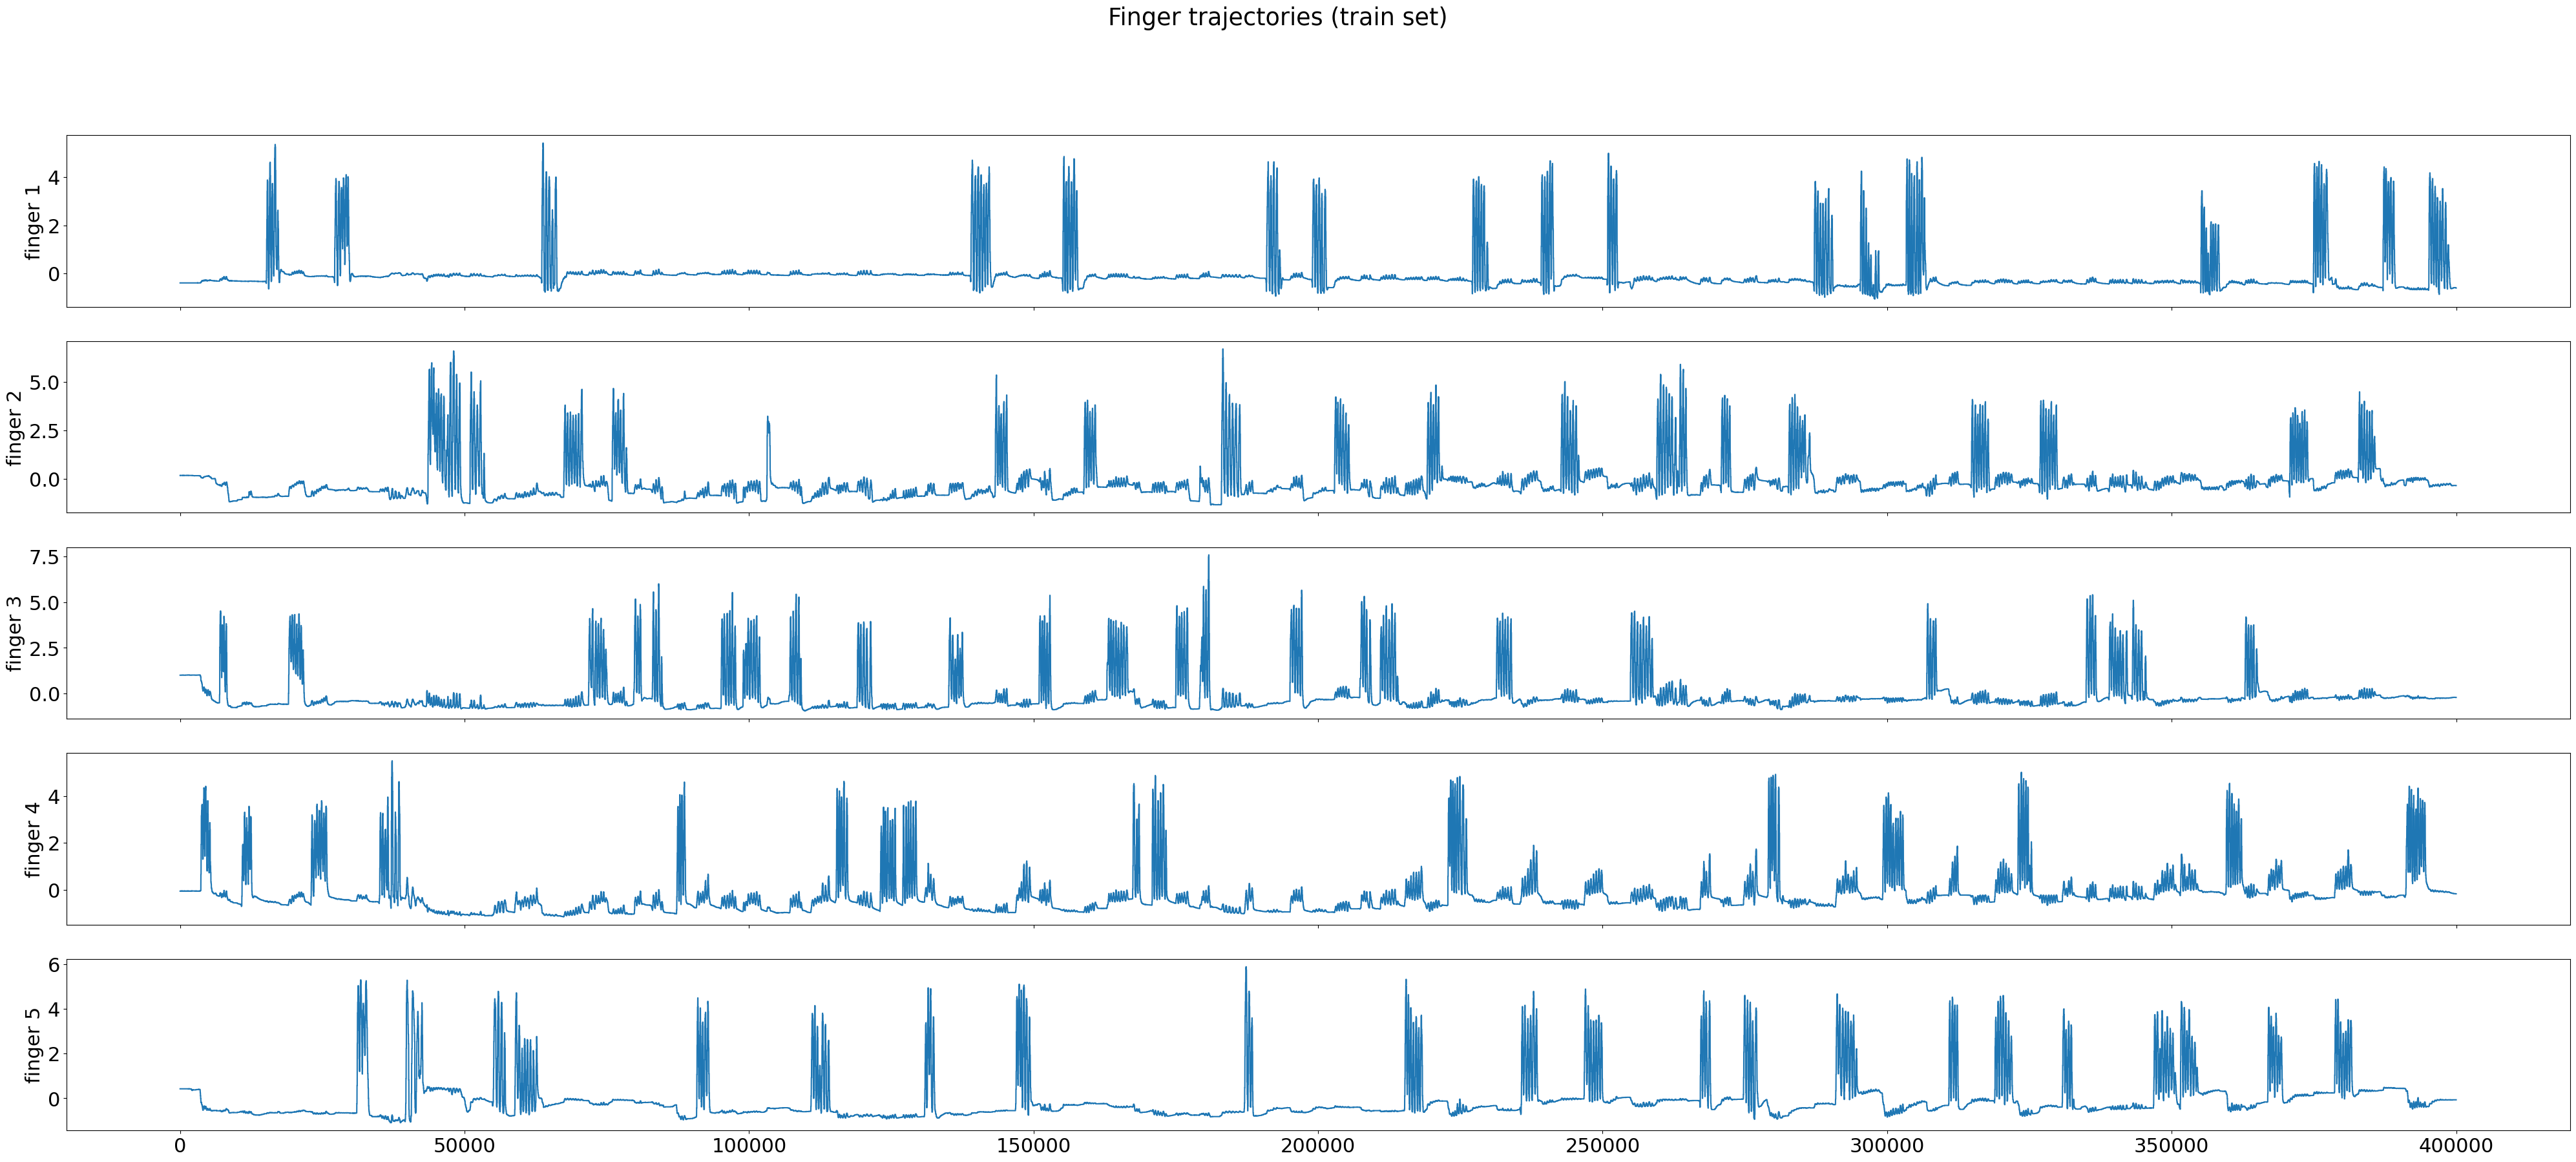

In [258]:
import matplotlib.pyplot as plt

n_fingers = subject_data.train_fingers.shape[1]


fig = plt.figure(figsize=(50,20))  # figure (width, height) in inches
fig.suptitle('Finger trajectories (train set)') #just to give the figure a title

# This creates a grid of subplots with n_fingers rows and 1 column,
axes = fig.subplots(nrows=n_fingers, ncols=1, sharex=True) 

for i in range(n_fingers):
    axes[i].plot(subject_data.train_fingers[:,i]) #this is what actually creates the plot for each finger, using all time samples (:) and the i-th finger (:,i)
    axes[i].set_ylabel(f'finger {i+1}')


#### 2.3.2 Visualize ECoG Signals

ECoG recordings are long and multi-channel. Plotting the full signal at once is usually too dense to read.

A much better strategy is to choose a short time window (delimitated by `start` and `end`) and select specific chanels (`selected_channels`).

In [259]:
import numpy as np
fs = 1000 #This is the sampling frequency of the data 
n_channels = subject_data.train_ecog.shape[1]
selected_channels = [0, 1, 2, 3, 54]

start_time = 0
end = 199_000

time = np.arange(start_time, end) / fs #This creates a time array that goes from 0 to 2 seconds, with a step of 1/fs (1 millisecond) between samples.

In the next plot, each subplot corresponds to one ECoG channel, and the horizontal axis is time in seconds.

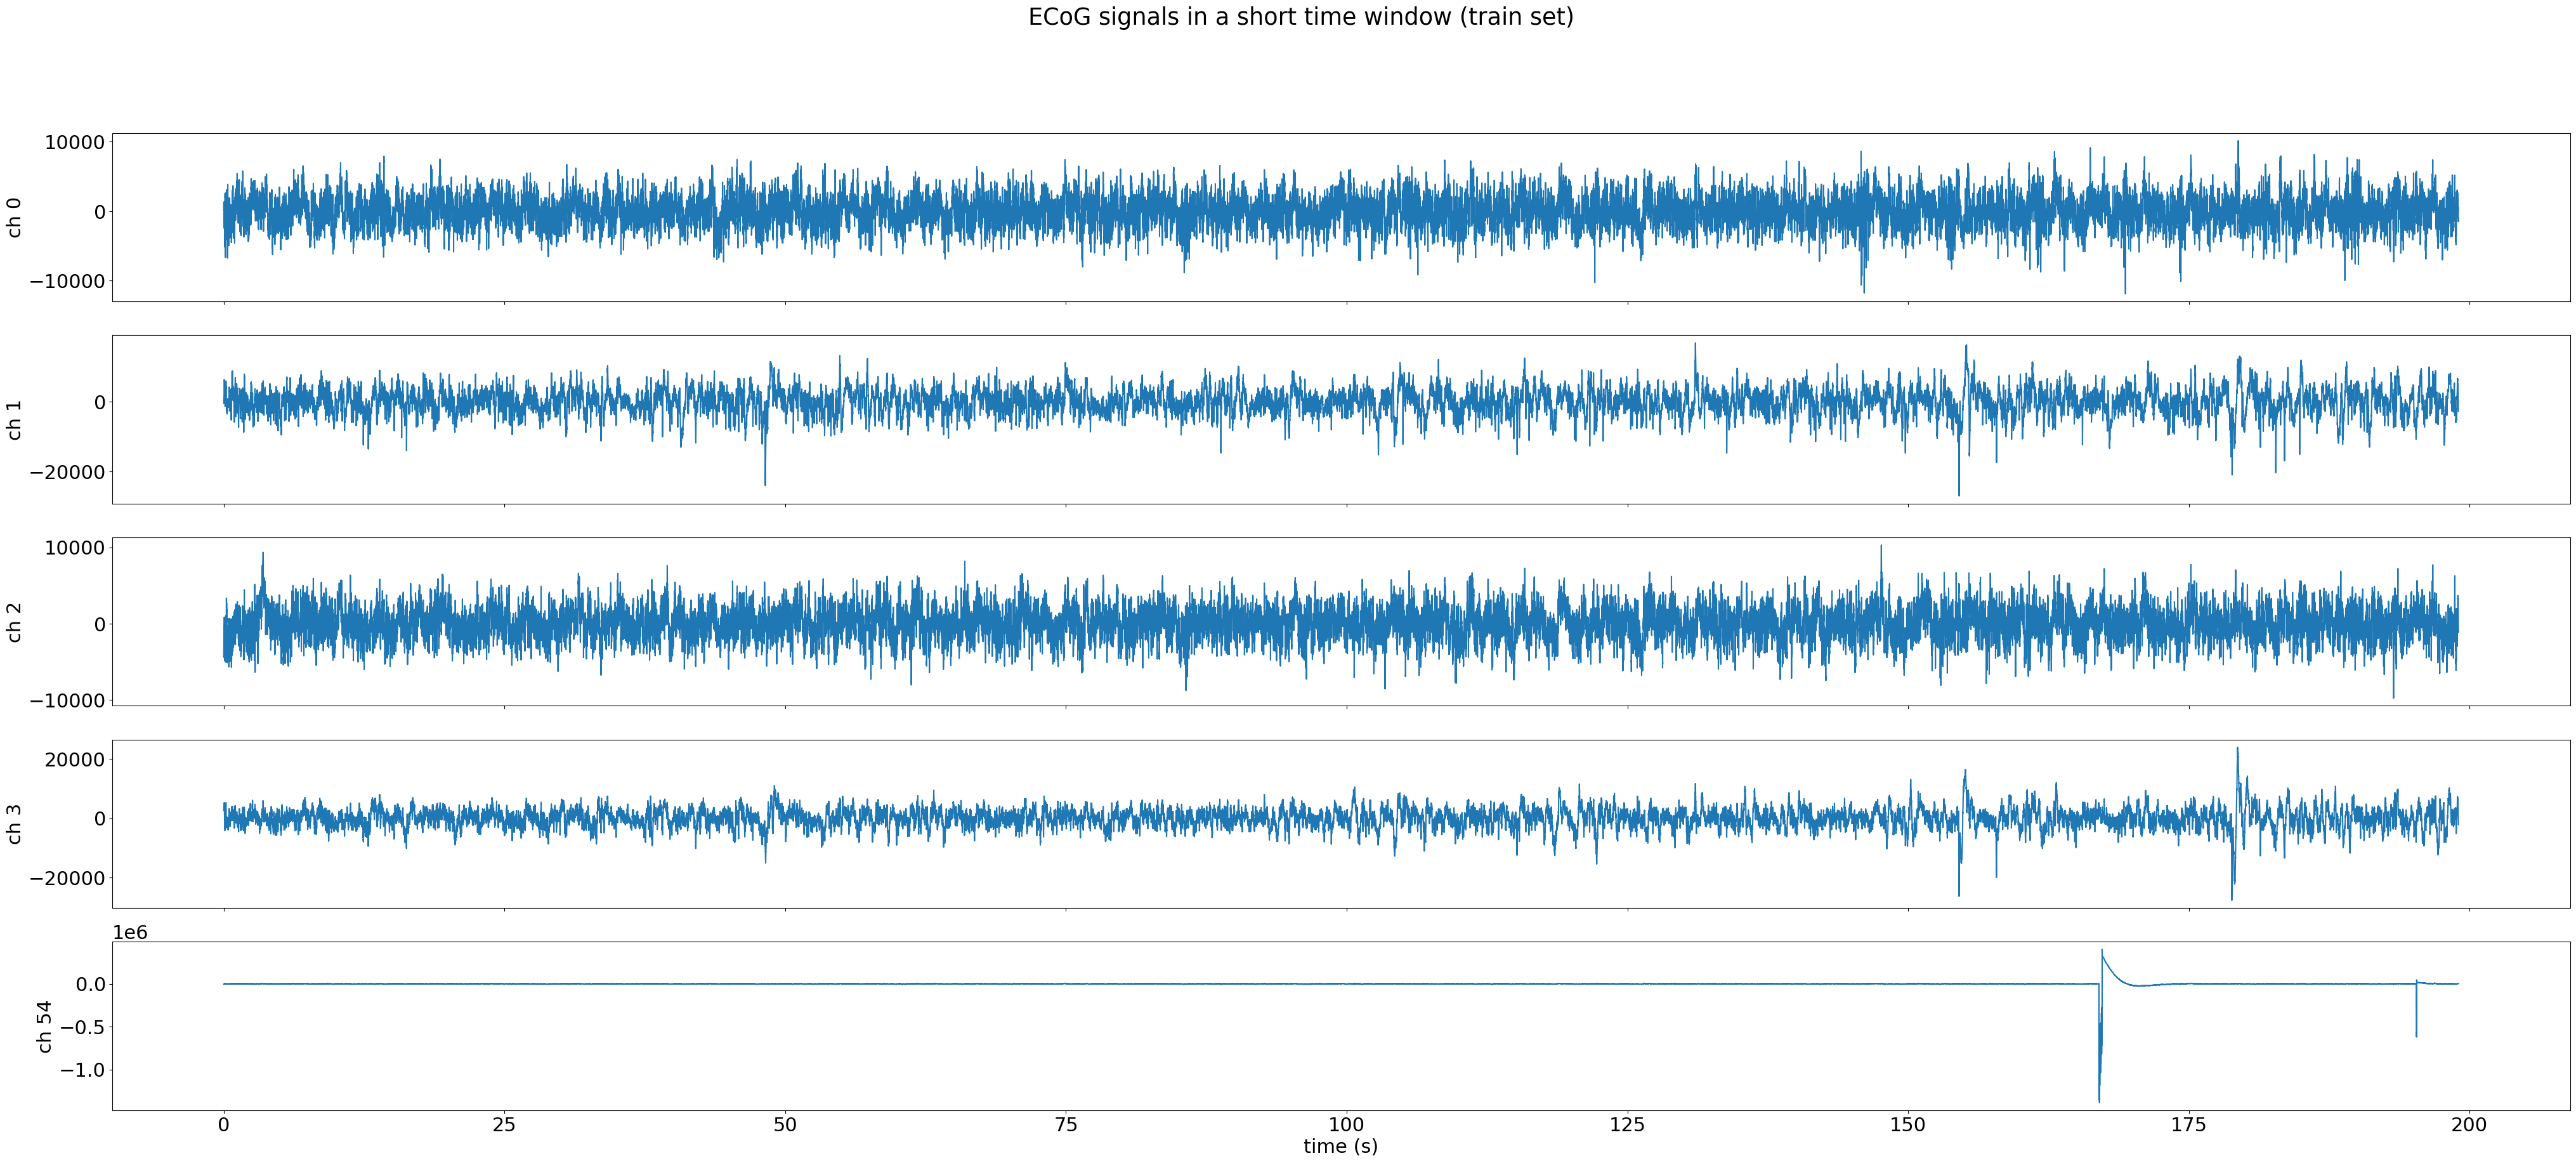

In [260]:
fig = plt.figure(figsize=(50,20))
fig.suptitle('ECoG signals in a short time window (train set)')
axes = fig.subplots(len(selected_channels), 1, sharex=True)
axes[-1].set_xlabel('time (s)')

for ax, channel in zip(axes, selected_channels):
    ax.plot(time, subject_data.train_ecog[start_time:end, channel])
    ax.set_ylabel(f'ch {channel}')


Note that the channel 54 present an artefact

# DECODING

Before building models, we first organize the notebook into three main steps.

First, in **Part 0**, we prepare the ECoG signal with a preprocessing pipeline that will be shared everywhere else in the notebook.

Then, in **Part 1**, we use these features for **discrete decoding**, where the goal is to predict which finger is moving.

Finally, in **Part 2**, we move to **continuous decoding**, where the goal is to reconstruct the finger trajectories themselves.


# Part 0: ECoG Preprocessing

This preprocessing block will be shared by both the discrete decoding workflow and the continuous decoding workflow.


## 0.1 Channel Selection

Some channels can be noisy or faulty. After previous visual inspection, we remove channel `54`.

We keep the remaining channels in `channel_selection`.


In [261]:
exclude_channels = [54]
n_channels = subject_data.train_ecog.shape[1]
channel_selection = [i for i in range(n_channels) if i not in exclude_channels]

print('number of selected channels:', len(channel_selection))


number of selected channels: 61


## 0.2 Artefact Removal With CAR

Some noise sources are shared across channels, for example line noise and its harmonics. A simple way to reduce this common activity is the **common average reference (CAR)**.

At each time point, we subtract the average across channels (one can also substract the median):

$$ECoG(c, t) = ECoG(c, t) - \frac{1}{N} \sum_{k=0}^{N-1} ECoG(k, t)$$

We apply CAR after removing the faulty channel.


In [262]:
ecog_train = tp.common_average_reference(subject_data.train_ecog[:, channel_selection], axis=1)
ecog_test = tp.common_average_reference(subject_data.test_ecog[:, channel_selection], axis=1)
ecog_train.shape # (40000, 61) time, nb_electrodes

(400000, 61)

## 0.3 Band Filtering

In ECoG, some frequency bands are commonly analyzed in the literature because they often carry useful information for decoding.

Here we use the helper function `tp.compute_band_filters` to get our filters.


In [263]:
from scipy.signal import sosfilt

bands = [(1, 10), (10, 30), (30, 50), (70, 200)]
band_filters = tp.compute_band_filters(bands)

train_ecog_filtered = [sosfilt(filt, ecog_train, axis=0) for filt in band_filters]
test_ecog_filtered = [sosfilt(filt, ecog_test, axis=0) for filt in band_filters]

X_train_filtered = np.concatenate(train_ecog_filtered, axis=1)
X_test_filtered = np.concatenate(test_ecog_filtered, axis=1)

X_train_filtered.shape #(400000, 244) time, nb_electrods x nb_filters

(400000, 244)

## 0.4 Power Features

We now convert the filtered ECoG signal into power features. For a centered signal $x$, the average power over a window of length $N$ is:

\begin{align}
P(x) = \frac{1}{N}\sum_{t}x^2(t),
\end{align}


We directly use `tp.buffering_power` for computing the power features.

We use `hop_size = 40`, which corresponds to one feature vector every 40 ms, that is a final sampling rate of `25 Hz`. This matches the temporal resolution used later for the discrete labels.


In [264]:
hop_size = 40
feature_win_size = 1000

X_train_features_full = tp.buffering_power(X_train_filtered, feature_win_size, hop_size)
X_test_full = tp.buffering_power(X_test_filtered, feature_win_size, hop_size)

print('X_train_features_full:', X_train_features_full.shape) # (10000, 244) time/hope_size, nb_electrodes x nb_filters
print('X_test_full:', X_test_full.shape)


X_train_features_full: (10000, 244)
X_test_full: (5000, 244)


# Part 1: Discrete Decoding

In this part, we turn the continuous finger trajectories into **discrete labels**, train a classifier, and evaluate the decoding performance.

The ECoG preprocessing and feature extraction were already prepared in **Part 0**.


## 1.1 Create Discrete Labels

We will build the labels in three explicit steps

1. **Downsampling**
2. **Smoothing**
3. **Thresholding**


### 1.1.1 Downsampling

The finger trajectories are sampled at `fs = 1000` Hz. We use `f_ratio = hop_size = 40` from Part 0 and keep one sample every `f_ratio` points.

This gives `train_fingers_downsampled` and `test_fingers_downsampled`.


In [265]:
import numpy as np

f_ratio = hop_size
threshold = 0.5
label_win_size = 25

n_times_train_full = subject_data.train_fingers.shape[0] // f_ratio
n_times_test = subject_data.test_fingers.shape[0] // f_ratio
n_fingers = subject_data.train_fingers.shape[1]

train_fingers_downsampled = subject_data.train_fingers[::f_ratio]
test_fingers_downsampled = subject_data.test_fingers[::f_ratio]


### 1.1.2 Smoothing

The downsampled trajectories can still be a bit jagged. We therefore smooth `train_fingers_downsampled` and `test_fingers_downsampled` with a moving-average window.

The window length is controlled by `label_win_size`, and the averaging kernel itself is stored in `label_win`.

This produces the variables `train_fingers_filtered` and `test_fingers_filtered`.


In [266]:
from scipy.signal import convolve

label_win = np.ones((label_win_size, 1)) / label_win_size

train_fingers_filtered = convolve(train_fingers_downsampled, label_win, 'same')
test_fingers_filtered = convolve(test_fingers_downsampled, label_win, 'same')


### 1.1.3 Thresholding

Finally, we compare the smoothed trajectories to a fixed value `threshold`.

At each time point, if all finger trajectories are below `threshold = 0.5`, we consider that the subject is in a `rest` state.

To represent this extra state, we concatenate one additional column filled with `threshold`. This creates `train_fingers_thresholded` and `test_fingers_thresholded`, with one supplementary column corresponding to the `rest` class.

Then we take the largest value with `argmax` to obtain the discrete labels `y_train_full` and `y_test`. For plotting convenience, we also build one-hot matrices `cue_train_full` and `cue_test`.


In [267]:
train_fingers_thresholded = np.concatenate((train_fingers_filtered, threshold * np.ones((n_times_train_full, 1))), axis=1)
test_fingers_thresholded = np.concatenate((test_fingers_filtered, threshold * np.ones((n_times_test, 1))), axis=1)

y_train_full = np.argmax(train_fingers_thresholded, axis=1)
y_test = np.argmax(test_fingers_thresholded, axis=1)

cue_train_full = np.zeros((n_times_train_full, n_fingers + 1))
cue_test = np.zeros((n_times_test, n_fingers + 1))
cue_train_full[np.arange(n_times_train_full), y_train_full] = 1
cue_test[np.arange(n_times_test), y_test] = 1


### Visualize The Labels

The figure below compares the three key variables built above:

- `train_fingers_downsampled`
- `train_fingers_filtered`
- `cue_train_full`

The legend identifies the five fingers, the `rest` class, and the black threshold line.


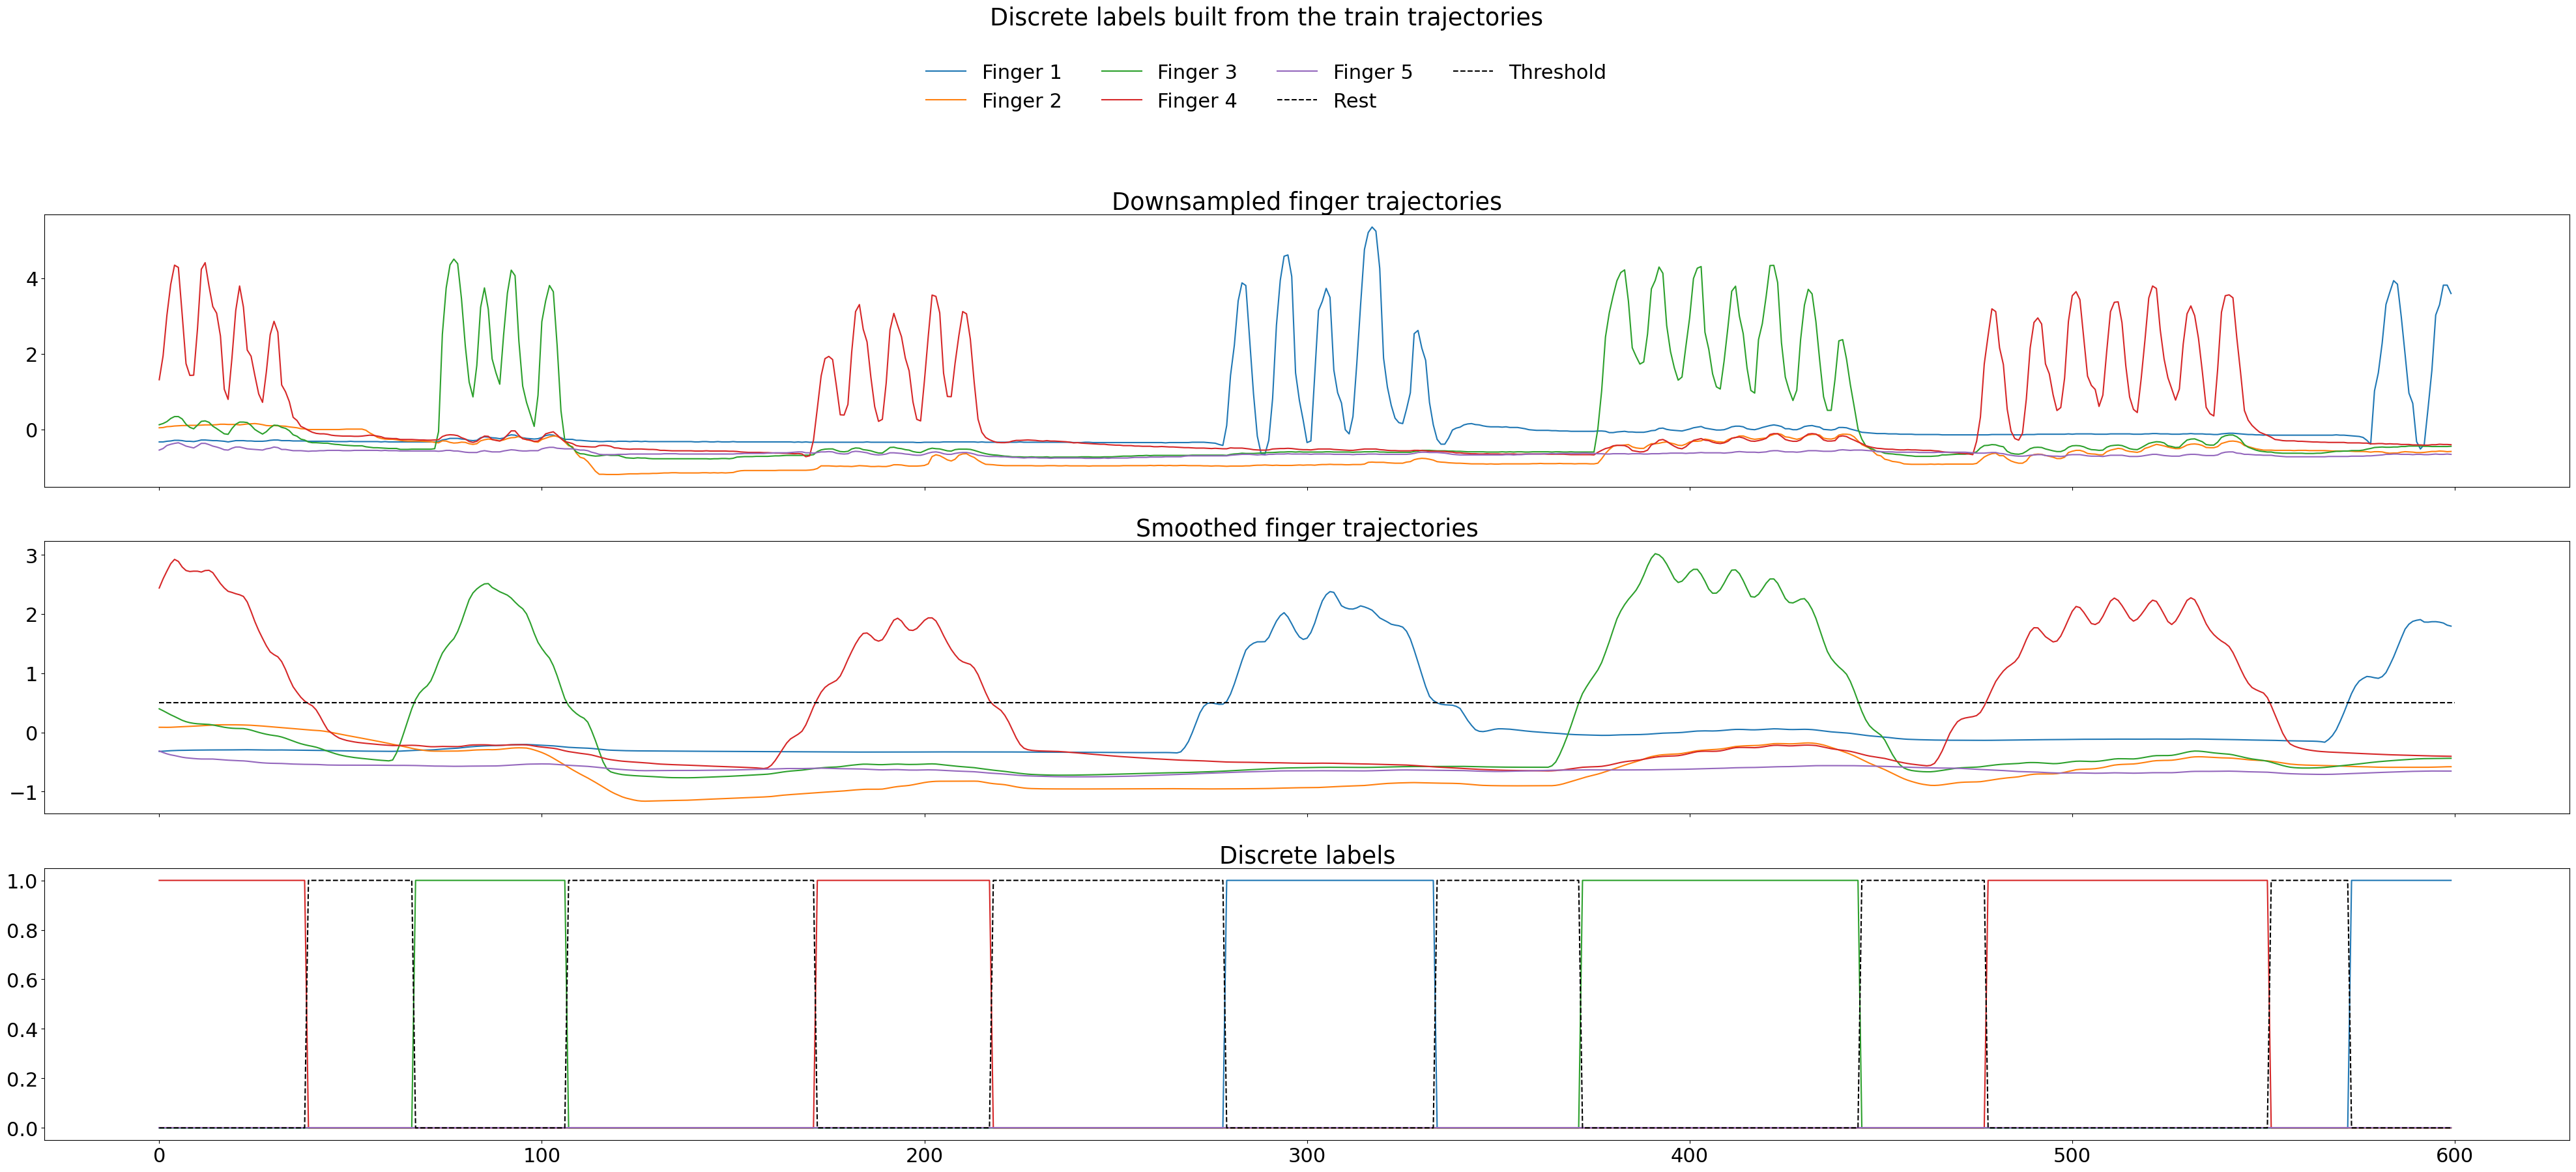

In [268]:
start_time = 100
end = 700

fig = plt.figure(figsize=(50, 20))
fig.suptitle('Discrete labels built from the train trajectories')

ax = fig.subplots(3, 1, sharex=True)
ax[0].set_title('Downsampled finger trajectories')
ax[1].set_title('Smoothed finger trajectories')
ax[2].set_title('Discrete labels')

finger_labels = [f'Finger {i + 1}' for i in range(n_fingers)]
finger_handles = []

for i in range(n_fingers):
    line, = ax[0].plot(train_fingers_downsampled[start_time:end, i], label=finger_labels[i])
    ax[1].plot(train_fingers_filtered[start_time:end, i], color=line.get_color())
    ax[2].plot(cue_train_full[start_time:end, i], color=line.get_color())
    finger_handles.append(line)

threshold_handle, = ax[1].plot([0, end - start_time], [threshold, threshold], color='k', linestyle='--', label='Threshold')
rest_handle, = ax[2].plot(cue_train_full[start_time:end, n_fingers], color='k', linestyle='--', label='Rest')

fig.subplots_adjust(top=0.82)
fig.legend(handles=finger_handles + [rest_handle, threshold_handle], loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95), frameon=False)


## 1.2 Split The Data Into Train / Validation / Test

We now split the original training set into a new training subset and a validation subset, while keeping the original test set untouched.


In [269]:
n_train_samples = int(0.8 * n_times_train_full)
train_slice = slice(0, n_train_samples)
val_slice = slice(n_train_samples, n_times_train_full)

X_train = X_train_features_full[train_slice]
X_val = X_train_features_full[val_slice]
X_test = X_test_full

y_train = y_train_full[train_slice]
y_val = y_train_full[val_slice]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('train labels:', y_train.shape)
print('validation labels:', y_val.shape)
print('test labels:', y_test.shape)


X_train: (8000, 244)
X_val: (2000, 244)
X_test: (5000, 244)
train labels: (8000,)
validation labels: (2000,)
test labels: (5000,)


## 1.3 Scikit-Learn And Model Usage

In scikit-learn, most estimators follow the same API:

- `fit(X, y)` trains the model;
- `predict(X)` returns predicted labels;
- `predict_proba(X)` returns class probabilities when the estimator supports them.

We start with a strong baseline: **Linear Discriminant Analysis (LDA)** with automatic shrinkage.

In LDA, each class is modeled with a Gaussian distribution that shares the same covariance matrix. The decision rule is:

$$\hat{y}(x) = \arg\max_k \; \delta_k(x)$$

with

$$\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log \pi_k$$

where `mu_k` is the mean of class `k`, `Sigma` is the shared covariance matrix, and `pi_k` is the prior probability of class `k`.


In [270]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

ESTIMATOR_KWARGS = {'solver': 'lsqr', 'shrinkage': 'auto'}
estimator = LDA(**ESTIMATOR_KWARGS)
estimator


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'lsqr'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",'auto'
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## 1.4 Train The Model

We first train the baseline model on the training split, then inspect both the validation and the test predictions.


In [271]:
estimator.fit(X_train, y_train)

y_val_pred = estimator.predict(X_val)
y_test_pred = estimator.predict(X_test)

## 1.5 Metrics

We will look at four standard classification metrics, plus a simple reference value called the **chance level**.

- **chance level**: the score expected from a uniform random guesser. If we have `n_classes`, the chance level is

$$\text{chance level} = \frac{1}{n_{\text{classes}}}$$

This is only a rough reference.

- **precision**: among the samples predicted as one class, how many are actually from that class.

$$\text{precision} = \frac{TP}{TP + FP}$$

- **recall**: among the samples that truly belong to one class, how many are correctly recovered by the model.

$$\text{recall} = \frac{TP}{TP + FN}$$

- **accuracy**: the overall fraction of correct predictions across all samples.

$$\text{accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}$$

- **F1-score**: the harmonic mean of precision and recall. It is more robust than accuracy because it penalizes both false positives and false negatives.

$$F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

- **confusion matrix**: a detailed view of which classes are confused with which others. Its coefficient `(i, j)` counts how many samples of true class `i` are predicted as class `j`.

Because we have multiple classes, we use **balanced accuracy** and **macro F1** so that each class has the same weight in the final metric:

- **balanced accuracy**: the average recall across classes.

$$\text{balanced accuracy} = \frac{1}{K} \sum_{k=1}^{K} \text{recall}_k$$

- **macro F1**: the average F1-score across classes.

$$\text{macro F1} = \frac{1}{K} \sum_{k=1}^{K} F_{1,k}$$

In short, `accuracy` gives a global score over all samples, while `balanced accuracy` and `macro F1` give the same importance to every class.


In [272]:
def print_classification_metrics(name, y_true, y_pred):
    n_classes = len(np.unique(y_true))
    chance_level = 1 / n_classes
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(name)
    print(f'  number of classes : {n_classes}')
    print(f'  chance level      : {chance_level:.3f}')
    print(f'  accuracy          : {acc:.3f}')
    print(f'  balanced accuracy : {bal_acc:.3f}')
    print(f'  macro F1          : {macro_f1:.3f}')

print_classification_metrics('Validation metrics (LDA)', y_val, y_val_pred)
print_classification_metrics('Test metrics (LDA)', y_test, y_test_pred)


Validation metrics (LDA)
  number of classes : 6
  chance level      : 0.167
  accuracy          : 0.491
  balanced accuracy : 0.476
  macro F1          : 0.484
Test metrics (LDA)
  number of classes : 6
  chance level      : 0.167
  accuracy          : 0.451
  balanced accuracy : 0.451
  macro F1          : 0.449


Text(0.5, 1.0, 'Confusion matrix (LDA on test set)')

<Figure size 800x800 with 0 Axes>

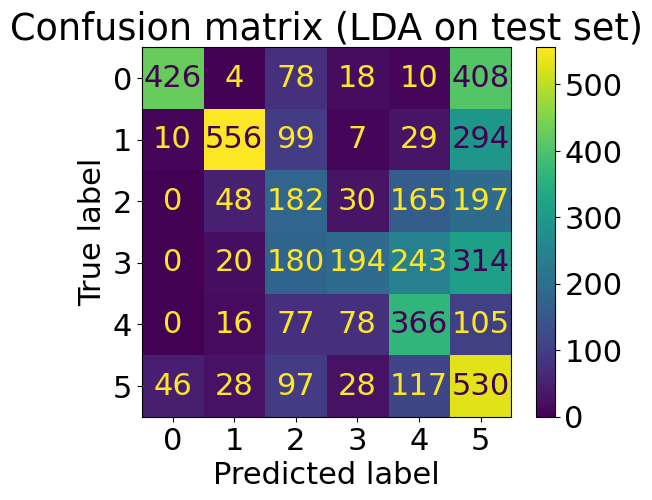

In [273]:
fig = plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title('Confusion matrix (LDA on test set)')


### Visualize Predictions Vs. Ground Truth

The next figure shows a short segment of the test set:

- the ground-truth labels `y_test`;
- the predicted labels `y_test_pred`;
- the class probabilities `y_test_proba`.

This makes it easier to see where the model is correct, where it makes mistakes, and how confident it is.


Text(0.5, 0.98, 'Prediction vs. ground truth on a short test segment')

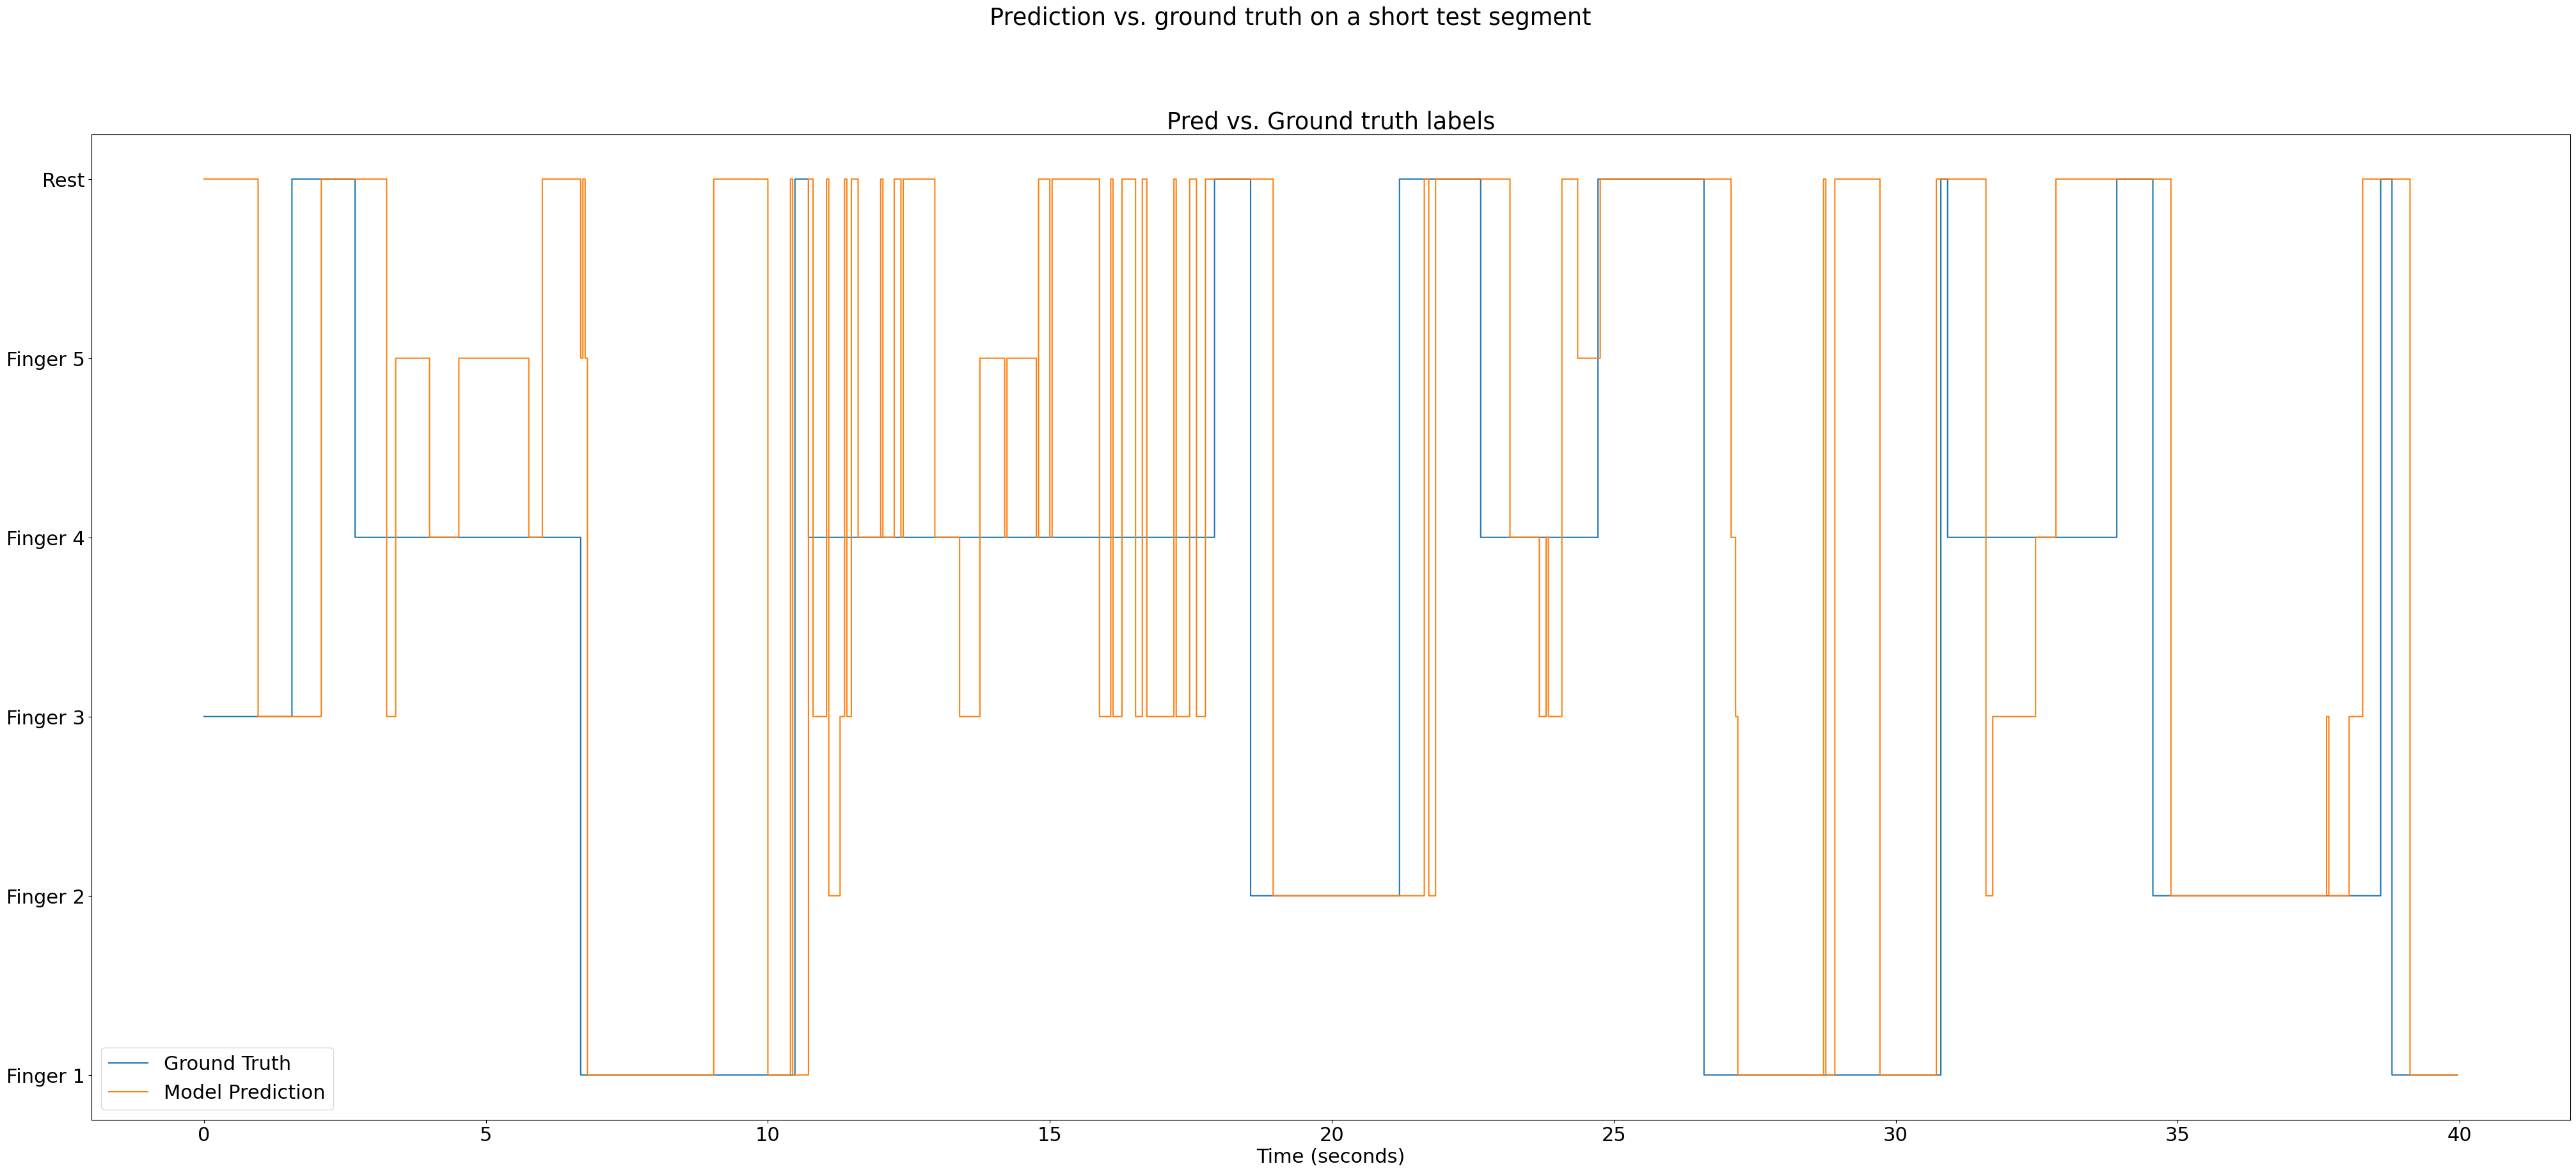

In [290]:
start_time = 0
end_time = min(1000, len(y_test))
time_axis = np.arange(start_time, end_time) / 25 #convenient way to see seconds in the figure for a data at 25-Hz.
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

fig, ax = plt.subplots(figsize=(50, 20))

line1 = ax.step(time_axis, y_test[start_time:end_time],  label="Ground Truth")
line2 = ax.step(time_axis, y_test_pred[start_time:end_time],  label="Model Prediction")
ax.set_title('Pred vs. Ground truth labels')
ax.set_yticks(range(len(class_labels)))
ax.set_yticklabels(class_labels)
ax.set_xlabel("Time (seconds)")
ax.legend()

fig.suptitle('Prediction vs. ground truth on a short test segment')


## 1.6 Advanced: Temporal Shift And Dimensionality Reduction

The ECoG signal and the finger label do not necessarily evolve at exactly the same time. In practice, the neural activity can appear slightly before or after the label we want to predict.

To account for this, we introduce a **temporal shift**: we shift the ECoG features with respect to the labels and keep the value that gives the best validation accuracy. Then we try PCA.


### 1.6.1 Find The Best Temporal Shift

We test several values of `shift_grid` on the validation set and keep the value `best_shift` that gives the best `balanced_accuracy_score`.

A negative shift means that the ECoG features are taken slightly earlier than the target label.


In [ ]:
def apply_temporal_shift(X, y, shift):
    n_times = X.shape[0]
    X_shifted = X[max(-shift, 0):min(n_times - shift, n_times)]
    y_shifted = y[max(shift, 0):min(n_times + shift, n_times)]
    return X_shifted, y_shifted

shift_grid = np.arange(-20, 21)
shift_scores = []

for shift in shift_grid:
    X_train_candidate, y_train_candidate = apply_temporal_shift(X_train, y_train, shift)
    X_val_candidate, y_val_candidate = apply_temporal_shift(X_val, y_val, shift)

    estimator_shift = LDA(**ESTIMATOR_KWARGS)
    estimator_shift.fit(X_train_candidate, y_train_candidate)
    y_val_pred_candidate = estimator_shift.predict(X_val_candidate)
    shift_scores.append(balanced_accuracy_score(y_val_candidate, y_val_pred_candidate))

best_shift = int(shift_grid[np.argmax(shift_scores)])
print(f'best_shift: {best_shift} samples ({best_shift / 25:.2f} s)')

plt.figure(figsize=(8, 4))
plt.plot(shift_grid, shift_scores, marker="o")
plt.axvline(best_shift, color="k", linestyle="--", label=f"best_shift = {best_shift}")
plt.xlabel("Temporal shift (samples)")
plt.ylabel("Validation balanced accuracy")
plt.title("Validation score as a function of temporal shift")
plt.legend()


### 1.6.2 Apply The Best Temporal Shift

We now build shifted train, validation, and test sets.


In [ ]:
X_train_shifted, y_train_shifted = apply_temporal_shift(X_train, y_train, best_shift)
X_val_shifted, y_val_shifted = apply_temporal_shift(X_val, y_val, best_shift)
X_test_shifted, y_test_shifted = apply_temporal_shift(X_test, y_test, best_shift)

print('X_train_shifted:', X_train_shifted.shape)
print('X_val_shifted:', X_val_shifted.shape)
print('X_test_shifted:', X_test_shifted.shape)


### 1.6.3 Train LDA With The Best Temporal Shift

We now train the baseline LDA again on the shifted features.


In [293]:
estimator_shift = LDA(**ESTIMATOR_KWARGS)
estimator_shift.fit(X_train_shifted, y_train_shifted)

y_val_pred_shift = estimator_shift.predict(X_val_shifted)
y_test_pred_shift = estimator_shift.predict(X_test_shifted)
y_test_proba_shift = estimator_shift.predict_proba(X_test_shifted)

print_classification_metrics('Validation metrics (temporal-shifted LDA)', y_val_shifted, y_val_pred_shift)
print_classification_metrics('Test metrics (temporal-shifted LDA)', y_test_shifted, y_test_pred_shift)


Validation metrics (temporal-shifted LDA)
  number of classes : 6
  chance level      : 0.167
  accuracy          : 0.529
  balanced accuracy : 0.521
  macro F1          : 0.524
Test metrics (temporal-shifted LDA)
  number of classes : 6
  chance level      : 0.167
  accuracy          : 0.497
  balanced accuracy : 0.494
  macro F1          : 0.493


### 1.6.4 PCA After Temporal Shift Correction

PCA stands for **Principal Component Analysis**. It is a classical dimensionality reduction method: it replaces the original feature space with a smaller set of directions that capture most of the variance in the data.

Mathematically, PCA projects the data onto the first principal components:

$$Z = X W_p$$

where `W_p` contains the `p` eigenvectors associated with the largest eigenvalues of the covariance matrix of `X`.

Here, we test several values in `pca_grid` on the validation set and keep the value `n_pca_components` that gives the best `balanced_accuracy_score`. We then train the same LDA model on the reduced features.


In [ ]:
candidate_components = [25, 50, 100, 150, 200, 250, 300]
max_components = min(X_train_shifted.shape[0], X_train_shifted.shape[1])
pca_grid = [n for n in candidate_components if n <= max_components]
pca_scores = []

for n_components in pca_grid:
    pca_candidate = PCA(n_components=n_components)
    X_train_pca_candidate = pca_candidate.fit_transform(X_train_shifted)
    X_val_pca_candidate = pca_candidate.transform(X_val_shifted)

    estimator_pca_candidate = LDA(**ESTIMATOR_KWARGS)
    estimator_pca_candidate.fit(X_train_pca_candidate, y_train_shifted)
    y_val_pred_candidate = estimator_pca_candidate.predict(X_val_pca_candidate)
    pca_scores.append(balanced_accuracy_score(y_val_shifted, y_val_pred_candidate))

n_pca_components = int(pca_grid[np.argmax(pca_scores)])
print(f'n_pca_components: {n_pca_components}')

plt.figure(figsize=(8, 4))
plt.plot(pca_grid, pca_scores, marker="o")
plt.axvline(n_pca_components, color="k", linestyle="--", label=f"n_pca_components = {n_pca_components}")
plt.xlabel("Number of PCA components")
plt.ylabel("Validation balanced accuracy")
plt.title("Validation score as a function of PCA dimension")
plt.legend()

pca = PCA(n_components=n_pca_components)
X_train_pca = pca.fit_transform(X_train_shifted)
X_val_pca = pca.transform(X_val_shifted)
X_test_pca = pca.transform(X_test_shifted)

estimator_pca = LDA(**ESTIMATOR_KWARGS)
estimator_pca.fit(X_train_pca, y_train_shifted)

y_val_pred_pca = estimator_pca.predict(X_val_pca)
y_test_pred_pca = estimator_pca.predict(X_test_pca)
y_test_proba_pca = estimator_pca.predict_proba(X_test_pca)

print_classification_metrics('Validation metrics (temporal shift + PCA + LDA)', y_val_shifted, y_val_pred_pca)
print_classification_metrics('Test metrics (temporal shift + PCA + LDA)', y_test_shifted, y_test_pred_pca)


## 1.6.5 Get A More Stable Output

A discrete decoder can be noisy from one prediction to the next. One simple trick is to smooth the class probabilities over time before taking the final `argmax`.

If `p_t` is the vector of class probabilities at time `t`, we compute a smoothed version

$$\tilde{p}_t = \sum_{\tau} w_{\tau} \, p_{t-\tau}$$

and then predict

$$\hat{y}_t = \arg\max_k \; \tilde{p}_{t,k}$$

Here we apply this idea to the probabilities produced by the `temporal shift + PCA + LDA` pipeline.


In [295]:
stable_win_size = 25
stable_win = np.expand_dims(np.hamming(stable_win_size), 1)

y_test_proba_stable = convolve(y_test_proba_pca, stable_win, 'same')
y_test_pred_stable = np.argmax(y_test_proba_stable, axis=1)

print_classification_metrics('Test metrics (stable temporal shift + PCA + LDA + Smoothing)', y_test_shifted, y_test_pred_stable)


Test metrics (stable temporal shift + PCA + LDA + Smoothing)
  number of classes : 6
  chance level      : 0.167
  accuracy          : 0.527
  balanced accuracy : 0.523
  macro F1          : 0.521


### 1.7.1 Visualize Predictions Vs. Ground Truth
Let see visually how we improved our model

Text(0.5, 0.98, 'Prediction vs. ground truth using Stable temporal shift + PCA + LDA + Smoothing ')

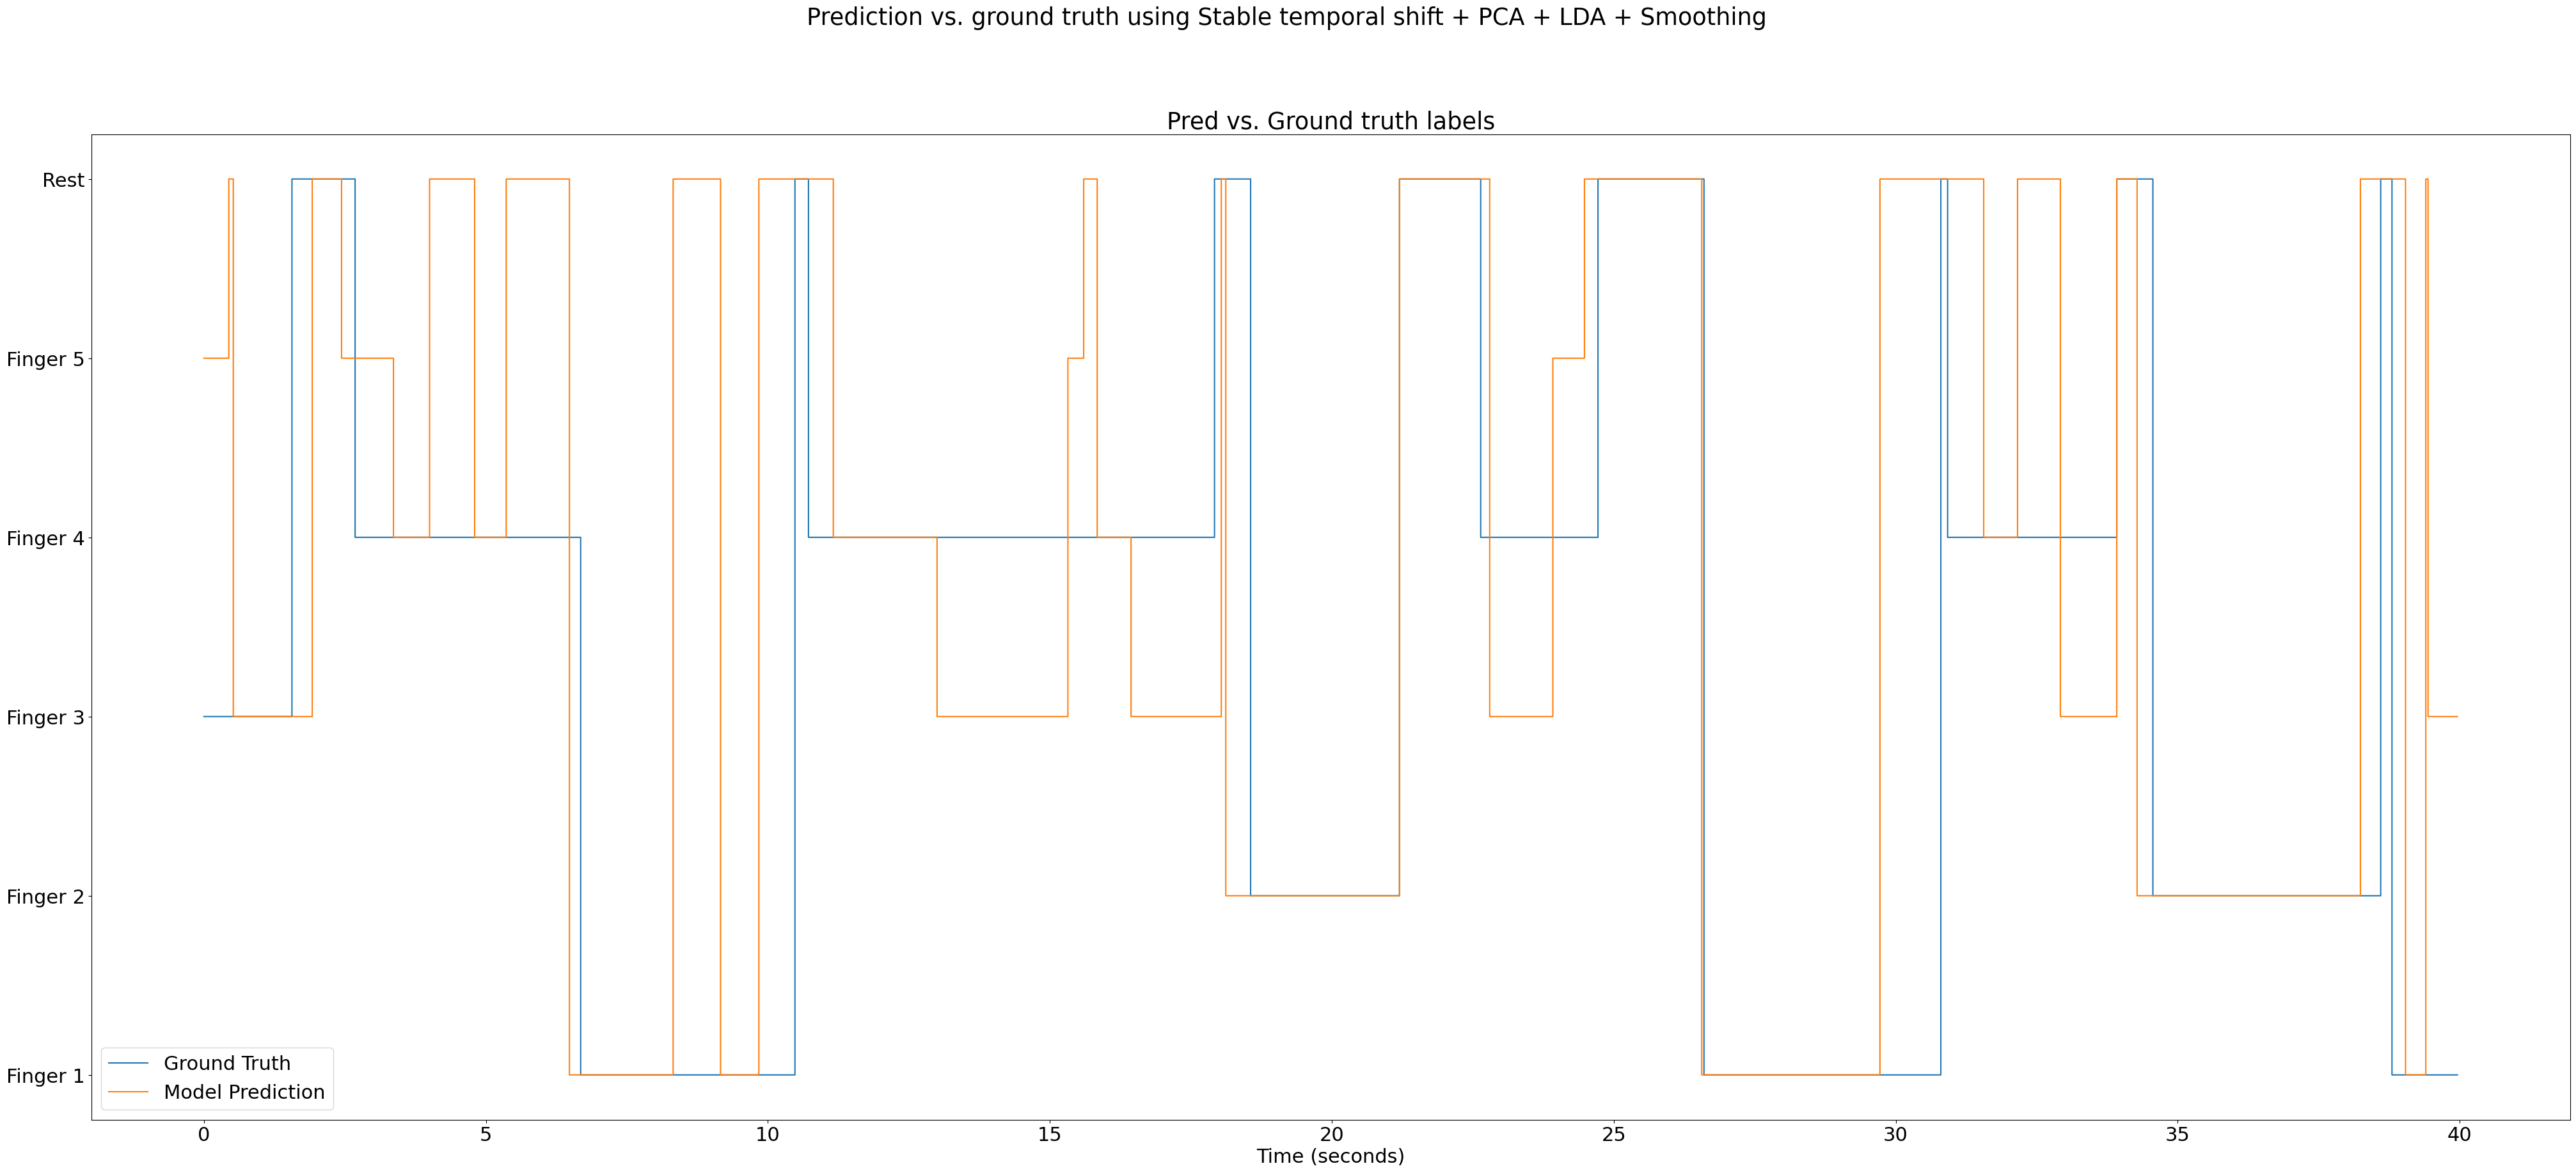

In [296]:
start_time = 0
end_time = min(1000, len(y_test))
time_axis = np.arange(start_time, end_time) / 25 #convenient way to see seconds in the figure for a data at 25-Hz.
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

fig, ax = plt.subplots(figsize=(50, 20))

line1 = ax.step(time_axis, y_test[start_time:end_time],  label="Ground Truth")
line2 = ax.step(time_axis, y_test_pred_stable[start_time:end_time],  label="Model Prediction")
ax.set_title('Pred vs. Ground truth labels')
ax.set_yticks(range(len(class_labels)))
ax.set_yticklabels(class_labels)
ax.set_xlabel("Time (seconds)")
ax.legend()

fig.suptitle('Prediction vs. ground truth using Stable temporal shift + PCA + LDA + Smoothing ')

# Part 2: Continuous Decoding

We now reuse the ECoG preprocessing from **Part 0** to predict continuous finger trajectories.


## 2.1 Prepare The Continuous Labels

In this part, the continuous label is simply the original finger trajectory.

We store it in `Y_train_position_full` for the training set and in `Y_test_position` for the test set.


In [281]:
Y_train_position_full = subject_data.train_fingers[::f_ratio]
Y_test_position = subject_data.test_fingers[::f_ratio]

print('X_train_features_full:', X_train_features_full.shape)
print('Y_train_position_full:', Y_train_position_full.shape)


X_train_features_full: (10000, 244)
Y_train_position_full: (10000, 5)


## 2.2 Split The Data

We keep the same temporal logic as before: the first part of the training signal is used for fitting, the second part for validation, and the original test set is kept for the final evaluation.


In [283]:
n_times_train_full = len(Y_train_position_full)
n_train = int(0.8 * n_times_train_full)
train_slice = slice(0, n_train)
val_slice = slice(n_train, n_times_train_full)

X_train = X_train_features_full[train_slice]
X_val = X_train_features_full[val_slice]

Y_train_position = Y_train_position_full[train_slice]
Y_val_position = Y_train_position_full[val_slice]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test_full.shape)


X_train: (8000, 244)
X_val: (2000, 244)
X_test: (5000, 244)


## 2.3 Linear Regression

We start with a simple baseline: a multi-output `LinearRegression` trained on the original position label.

The model assumes a linear relationship between the features and the continuous target:

$$\hat{Y} = XW + b$$

where `X` is the feature matrix, `W` contains the regression coefficients, and `b` is the intercept.

The fitted coefficients are chosen to minimize the squared error:

$$\min_{W,b} \; ||Y - (XW + b)||_2^2$$


In [284]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

linear_model = LinearRegression()
linear_model.fit(X_train, Y_train_position)

Y_val_pred_linear = linear_model.predict(X_val)
Y_test_pred_linear = linear_model.predict(X_test_full)


## 2.4 Regression Metrics

We use three standard metrics:

- `R2`: how much variance is explained by the model.

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

A value close to `1` is good, `0` means that the model is not better than predicting the mean, and negative values mean that the model is worse than that simple baseline.

- `MSE`: the average squared error.

$$\text{MSE} = \frac{1}{N} \sum_i (y_i - \hat{y}_i)^2$$

Smaller values are better, and `0` would mean perfect predictions. Its absolute scale depends on the scale of the finger trajectories, so it is mostly useful for comparing models on the same task.

- `correlation`: how well the predicted trajectory follows the shape of the true trajectory.

$$\rho(y, \hat{y}) = \frac{\sum_i (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_i (y_i - \bar{y})^2} \sqrt{\sum_i (\hat{y}_i - \bar{\hat{y}})^2}}$$

A value close to `1` is good, a value near `0` means little or no linear relationship, and a negative value means that the prediction tends to move in the opposite direction.

In practice, a good model should have high `R2`, low `MSE`, and high positive `correlation`.


In [285]:
def compute_regression_metrics(Y_true, Y_pred):
    r2_values = []
    mse_values = []
    corr_values = []
    for finger in range(Y_true.shape[1]):
        y_true_f = Y_true[:, finger]
        y_pred_f = Y_pred[:, finger]
        r2_values.append(r2_score(y_true_f, y_pred_f))
        mse_values.append(mean_squared_error(y_true_f, y_pred_f))
        if np.std(y_true_f) < 1e-12 or np.std(y_pred_f) < 1e-12:
            corr_values.append(0.0)
        else:
            corr_values.append(np.corrcoef(y_true_f, y_pred_f)[0, 1])
    return np.array(r2_values), np.array(mse_values), np.array(corr_values)

def print_regression_metrics(name, Y_true, Y_pred):
    r2_values, mse_values, corr_values = compute_regression_metrics(Y_true, Y_pred)
    print(name)
    print(f'  mean R2          : {r2_values.mean():.3f}')
    print(f'  mean MSE         : {mse_values.mean():.3f}')
    print(f'  mean correlation : {corr_values.mean():.3f}')
    print()
    for finger in range(Y_true.shape[1]):
        print(f'  finger {finger + 1}: R2={r2_values[finger]:.3f}, MSE={mse_values[finger]:.3f}, corr={corr_values[finger]:.3f}')

print_regression_metrics('Validation metrics (Linear Regression)', Y_val_position, Y_val_pred_linear)
print_regression_metrics('Test metrics (Linear Regression)', Y_test_position, Y_test_pred_linear)


Validation metrics (Linear Regression)
  mean R2          : -0.168
  mean MSE         : 0.966
  mean correlation : 0.350

  finger 1: R2=0.099, MSE=0.763, corr=0.405
  finger 2: R2=0.126, MSE=0.543, corr=0.572
  finger 3: R2=-0.815, MSE=1.443, corr=0.001
  finger 4: R2=-0.192, MSE=0.970, corr=0.444
  finger 5: R2=-0.056, MSE=1.113, corr=0.329
Test metrics (Linear Regression)
  mean R2          : -0.396
  mean MSE         : 1.190
  mean correlation : 0.321

  finger 1: R2=0.170, MSE=1.311, corr=0.413
  finger 2: R2=-0.123, MSE=0.737, corr=0.605
  finger 3: R2=-1.129, MSE=1.347, corr=0.048
  finger 4: R2=-0.425, MSE=1.391, corr=0.334
  finger 5: R2=-0.476, MSE=1.164, corr=0.204


## 2.5 Ridge Regression

We now add an `L2` regularization term with `Ridge`. Here, we start with a fixed value `ridge_alpha = 10000.0` as a simple baseline, before the per-finger hyperparameter search introduced later.

Ridge keeps the same linear model

$$\hat{Y} = XW + b$$

but changes the objective function by penalizing large coefficients:

$$\min_{W,b} \; ||Y - (XW + b)||_2^2 + \alpha ||W||_2^2$$

The parameter `alpha` controls the strength of the regularization.


In [286]:
ridge_alpha = 10000.0
ridge_model = Ridge(alpha=ridge_alpha)
ridge_model.fit(X_train, Y_train_position)

Y_val_pred_ridge = ridge_model.predict(X_val)
Y_test_pred_ridge = ridge_model.predict(X_test_full)

print_regression_metrics('Validation metrics (Ridge)', Y_val_position, Y_val_pred_ridge)
print_regression_metrics('Test metrics (Ridge)', Y_test_position, Y_test_pred_ridge)


Validation metrics (Ridge)
  mean R2          : -0.168
  mean MSE         : 0.966
  mean correlation : 0.350

  finger 1: R2=0.099, MSE=0.763, corr=0.405
  finger 2: R2=0.126, MSE=0.543, corr=0.572
  finger 3: R2=-0.815, MSE=1.443, corr=0.001
  finger 4: R2=-0.192, MSE=0.970, corr=0.444
  finger 5: R2=-0.056, MSE=1.113, corr=0.329
Test metrics (Ridge)
  mean R2          : -0.396
  mean MSE         : 1.190
  mean correlation : 0.321

  finger 1: R2=0.170, MSE=1.311, corr=0.413
  finger 2: R2=-0.123, MSE=0.737, corr=0.605
  finger 3: R2=-1.129, MSE=1.347, corr=0.048
  finger 4: R2=-0.425, MSE=1.391, corr=0.334
  finger 5: R2=-0.476, MSE=1.164, corr=0.204


### Visualize Ridge Metrics And Predictions

We compare `Linear Regression` and `Ridge` finger by finger, then we plot the predicted and true trajectories on a short segment of the test set.


Text(0.5, 0.98, 'Ridge predictions vs ground truth on a short test segment')

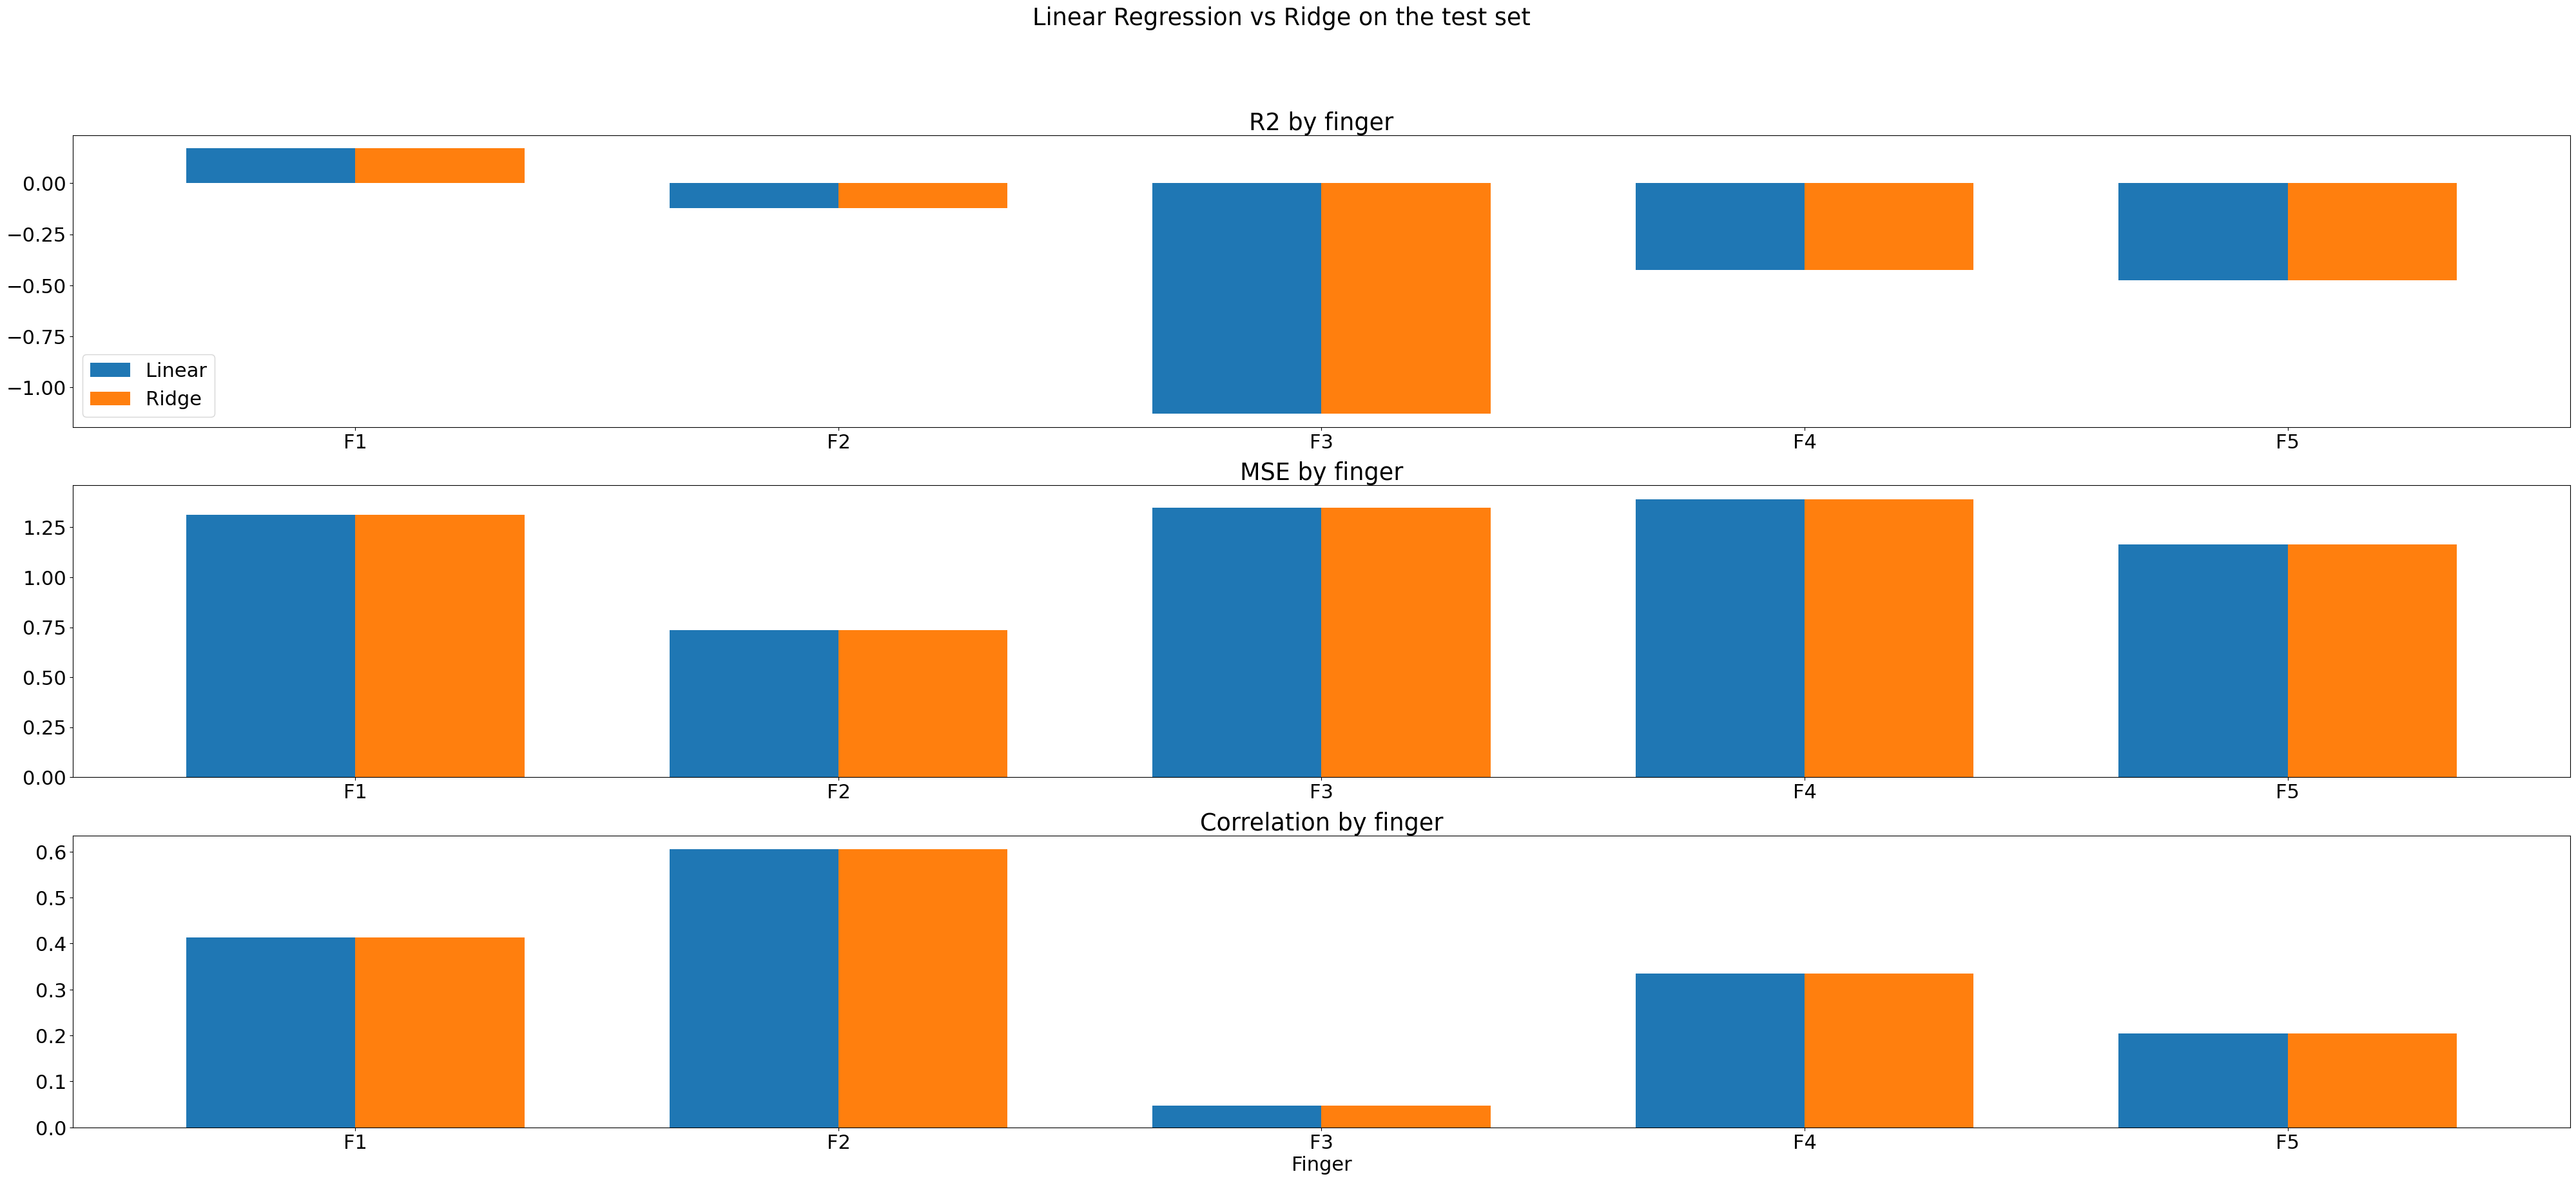

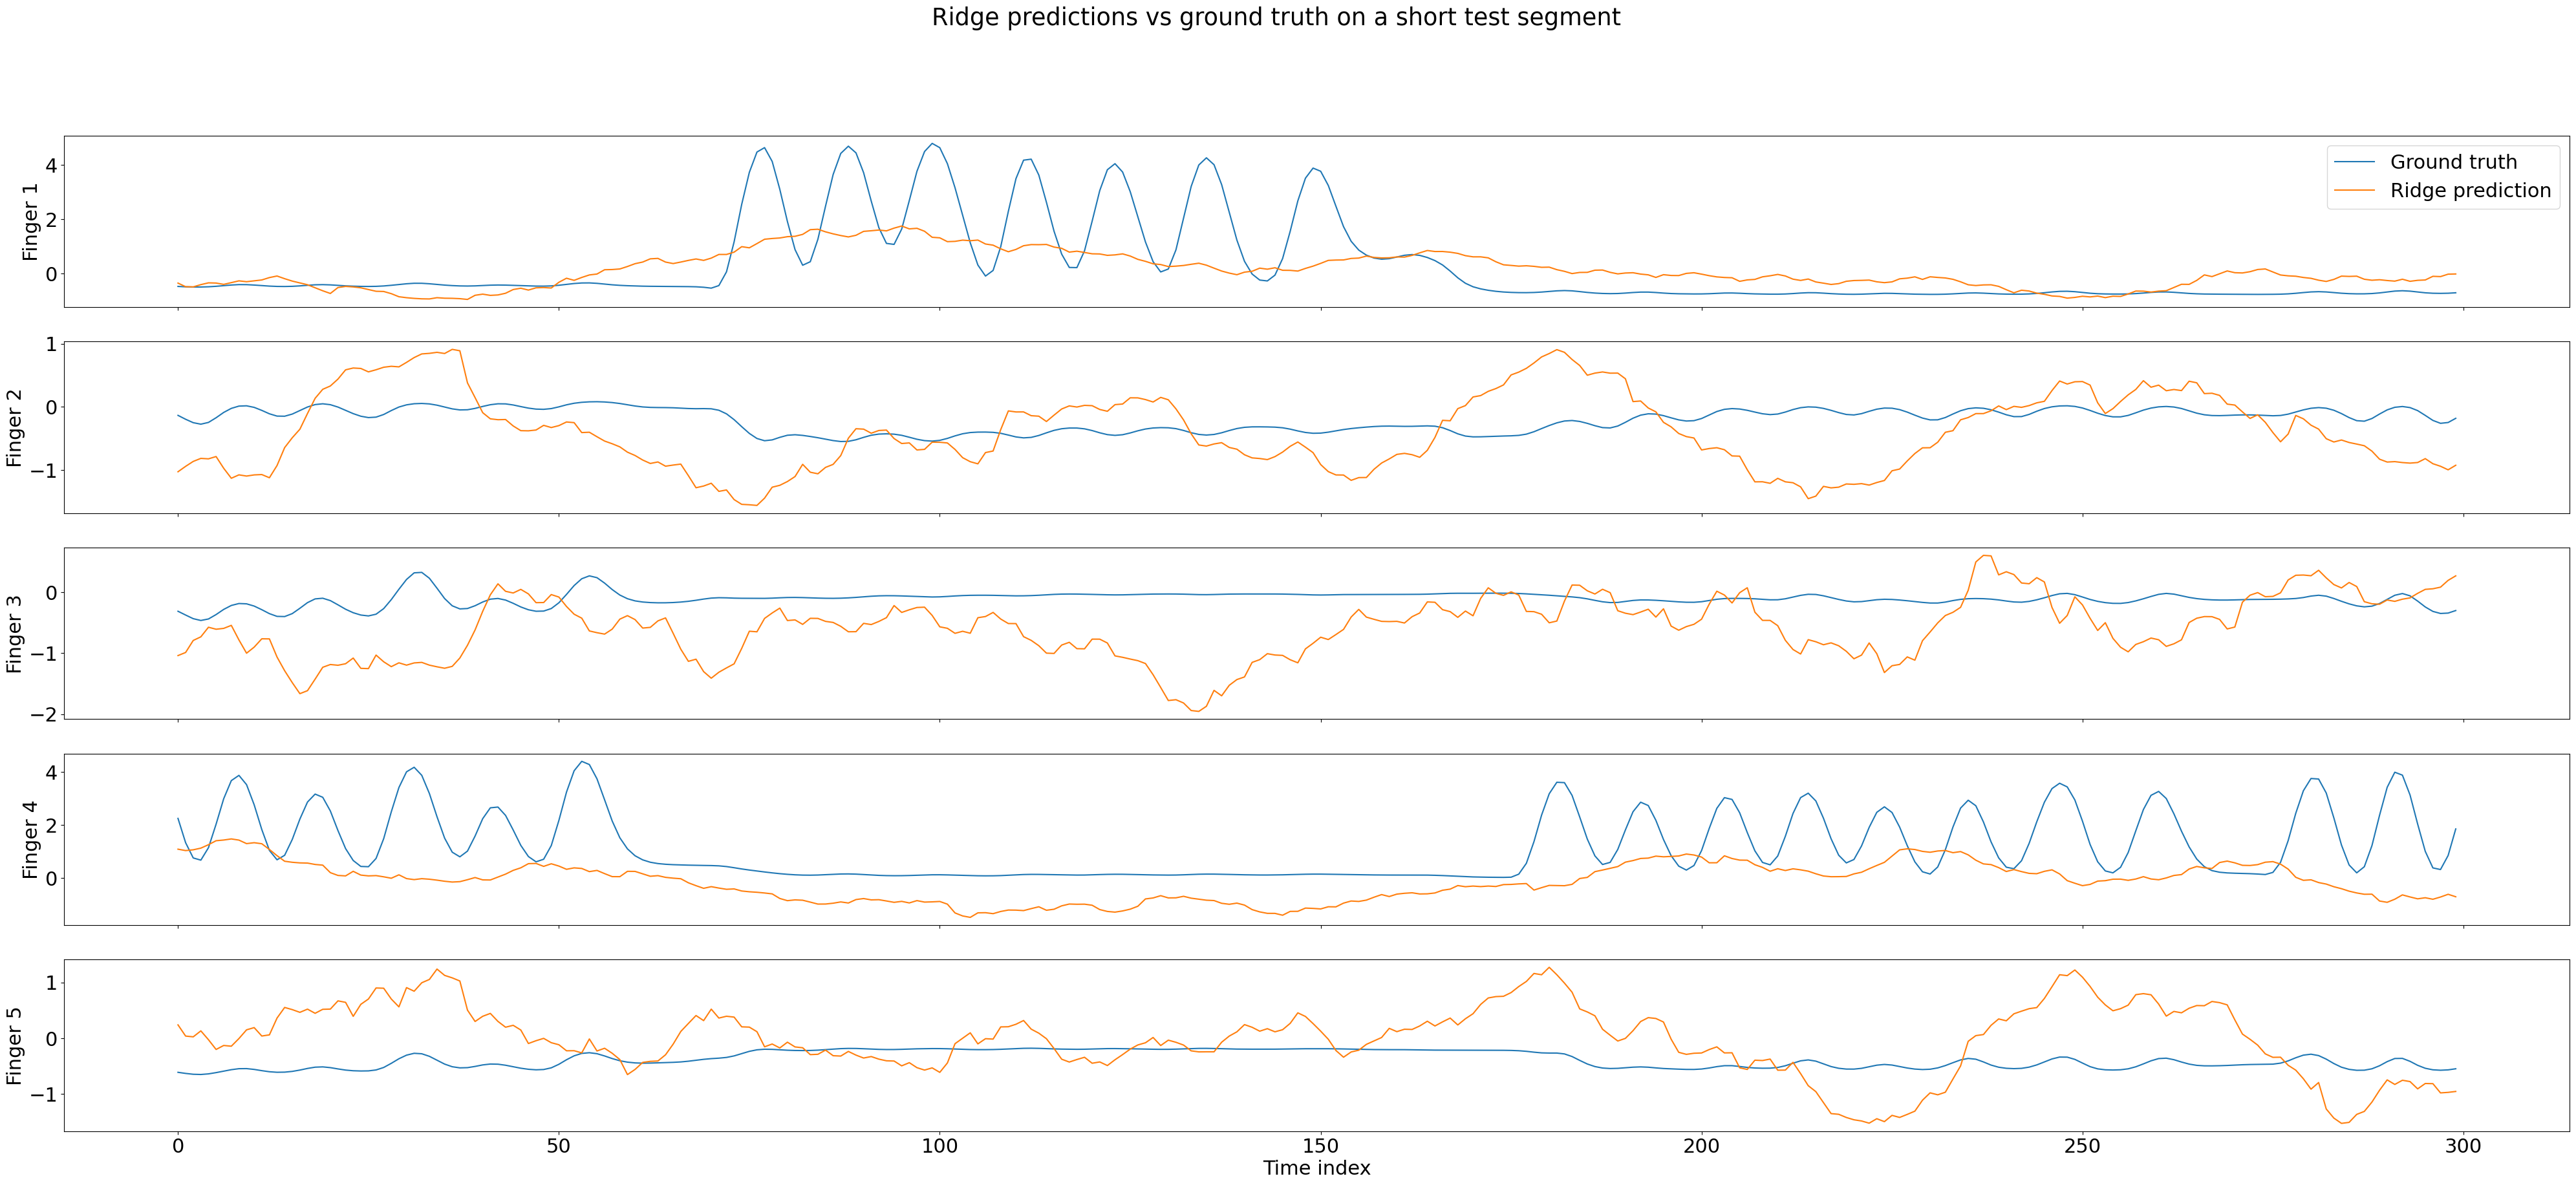

In [287]:
linear_r2, linear_mse, linear_corr = compute_regression_metrics(Y_test_position, Y_test_pred_linear)
ridge_r2, ridge_mse, ridge_corr = compute_regression_metrics(Y_test_position, Y_test_pred_ridge)
fingers = np.arange(n_fingers)
bar_width = 0.35

fig = plt.figure(figsize=(50, 20))
ax = fig.subplots(3, 1)
ax[0].bar(fingers - bar_width / 2, linear_r2, width=bar_width, label='Linear')
ax[0].bar(fingers + bar_width / 2, ridge_r2, width=bar_width, label='Ridge')
ax[0].set_title('R2 by finger')
ax[0].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[0].legend()

ax[1].bar(fingers - bar_width / 2, linear_mse, width=bar_width, label='Linear')
ax[1].bar(fingers + bar_width / 2, ridge_mse, width=bar_width, label='Ridge')
ax[1].set_title('MSE by finger')
ax[1].set_xticks(fingers, [f'F{i + 1}' for i in fingers])

ax[2].bar(fingers - bar_width / 2, linear_corr, width=bar_width, label='Linear')
ax[2].bar(fingers + bar_width / 2, ridge_corr, width=bar_width, label='Ridge')
ax[2].set_title('Correlation by finger')
ax[2].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[2].set_xlabel('Finger')

fig.suptitle('Linear Regression vs Ridge on the test set')

start_time = 100
end_time = min(400, len(Y_test_position))

fig = plt.figure(figsize=(50, 20))
ax = fig.subplots(n_fingers, 1, sharex=True)
for finger in range(n_fingers):
    ax[finger].plot(Y_test_position[start_time:end_time, finger], label='Ground truth')
    ax[finger].plot(Y_test_pred_ridge[start_time:end_time, finger], label='Ridge prediction')
    ax[finger].set_ylabel(f'Finger {finger + 1}')
ax[0].legend(loc='upper right')
ax[-1].set_xlabel('Time index')
fig.suptitle('Ridge predictions vs ground truth on a short test segment')


## 2.6 Advanced: Find The Best Temporal Shift And Alpha For Each Finger

For each finger, we still use the same Ridge model

$$\hat{y} = Xw + b$$

with the Ridge objective

$$\min_{w,b} \; ||y - (Xw + b)||_2^2 + \alpha ||w||_2^2$$

but we now test several values in `shift_grid` and `alpha_grid` on the validation set, independently for each finger.

We then keep the pair `(best_shift, best_alpha)` that gives the highest validation correlation.


In [ ]:
shift_grid = np.arange(-10, 11)
alpha_grid = np.logspace(-4, 4, 9)

best_shifts_per_finger = np.zeros(n_fingers, dtype=int)
best_alphas_per_finger = np.zeros(n_fingers, dtype=float)
best_val_corr_per_finger = np.zeros(n_fingers, dtype=float)

for finger in range(n_fingers):
    best_score = -np.inf

    for shift in shift_grid:
        y_train_shifted_finger = tp.lag(Y_train_position[:, finger], shift)
        y_val_shifted_finger = tp.lag(Y_val_position[:, finger], shift)

        for alpha in alpha_grid:
            model = Ridge(alpha=float(alpha))
            model.fit(X_train, y_train_shifted_finger)
            y_val_pred_finger = model.predict(X_val)

            if np.std(y_val_shifted_finger) < 1e-12 or np.std(y_val_pred_finger) < 1e-12:
                score = 0.0
            else:
                score = np.corrcoef(y_val_shifted_finger, y_val_pred_finger)[0, 1]

            if score > best_score:
                best_score = score
                best_shifts_per_finger[finger] = int(shift)
                best_alphas_per_finger[finger] = float(alpha)
                best_val_corr_per_finger[finger] = float(score)

Y_test_position_tuned = np.zeros_like(Y_test_position)
Y_test_position_target_tuned = np.zeros_like(Y_test_position)

for finger in range(n_fingers):
    best_shift = int(best_shifts_per_finger[finger])
    best_alpha = float(best_alphas_per_finger[finger])

    y_train_full_shifted_finger = tp.lag(Y_train_position_full[:, finger], best_shift)
    y_test_shifted_finger = tp.lag(Y_test_position[:, finger], best_shift)

    tuned_model = Ridge(alpha=best_alpha)
    tuned_model.fit(X_train_features_full, y_train_full_shifted_finger)
    Y_test_position_tuned[:, finger] = tuned_model.predict(X_test_full)
    Y_test_position_target_tuned[:, finger] = y_test_shifted_finger

print('best_shifts_per_finger:', best_shifts_per_finger)
print('best_alphas_per_finger:', best_alphas_per_finger)
print('best_val_corr_per_finger:', np.round(best_val_corr_per_finger, 3))
print_regression_metrics('Test metrics (tuned Ridge)', Y_test_position_target_tuned, Y_test_position_tuned)


In [ ]:
fig = plt.figure(figsize=(50, 20))
ax = fig.subplots(3, 1)
fingers = np.arange(n_fingers)

ax[0].bar(fingers, best_shifts_per_finger)
ax[0].set_title('Best temporal shift per finger')
ax[0].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[0].set_ylabel('Temporal shift (samples)')

ax[1].bar(fingers, best_alphas_per_finger)
ax[1].set_title('Best alpha per finger')
ax[1].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[1].set_ylabel('Alpha')
ax[1].set_yscale('log')

ax[2].bar(fingers, best_val_corr_per_finger)
ax[2].set_title('Best validation correlation per finger')
ax[2].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[2].set_ylabel('Correlation')

start_time = 100
end_time = min(400, len(Y_test_position_tuned))

fig = plt.figure(figsize=(50, 20))
ax = fig.subplots(n_fingers, 1, sharex=True)
for finger in range(n_fingers):
    ax[finger].plot(Y_test_position_target_tuned[start_time:end_time, finger], label='Ground truth')
    ax[finger].plot(Y_test_position_tuned[start_time:end_time, finger], label='Tuned ridge')
    ax[finger].set_ylabel(f'Finger {finger + 1}')
ax[0].legend(loc='upper right')
ax[-1].set_xlabel('Time index')
fig.suptitle('Tuned Ridge predictions vs ground truth on the test set')
